In [3]:
# Instalamos las dependencias necesarias para el proyecto

!python -m pip install pandas
!python -m pip install numpy
!python -m pip install scikit.learn
!python -m pip install matplotlib
!python -m pip install seaborn
!python -m pip install plotly
!python -m pip install -U nbformat


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Importamos los paquetes que luego se utilizarán. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [5]:
# Transformamos el dataset a un df y lo visualizamos para tener noción sobre qué hay dentro.
data = pd.read_csv("uber_fares.csv")
data.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [6]:
print(data.shape) # (fila, columna)          
print(data.dtypes) # Tipo de dato por columna

(200000, 9)
key                    int64
date                     str
fare_amount          float64
pickup_datetime          str
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object


Con esto podemos ver que hay 200.000 registros, cada uno con 9 columnas (['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']).

Además, vemos que 'date' y 'pickup_datetime' son str, esto lo modificaremos más adelante para un correcto uso de la información que poseen estas columnas.  

In [7]:
# Para iniciar la limpieza revisamos si hay datos duplicados. 

duplicados_totales = data.duplicated().sum()
duplicados_key = data["key"].duplicated().sum()

print("Duplicados totales:", duplicados_totales)
print("Duplicados en key:", duplicados_key)

vacios = data.isna().sum()

print(f"\n {vacios}")


Duplicados totales: 0
Duplicados en key: 0

 key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


Revisamos los duplicados tanto de los registros completos como de las key. Este último debido a que al ser el identificador de cada viaje, demostraría una inconsistencia en el dataset en caso de duplicados. 

También podemos ver que hay un viaje que no tiene dropoff_longitude ni dropoff_latitude, como si nunca hubiese terminado. Decidimos eliminarlo, ya que lo consideramos un dato que puede generar ruido en el modelo y no es significativo a la cantidad de registros. 

In [8]:
data = data.dropna()

In [9]:
pickup_sin_tz = data["pickup_datetime"].str.split(" ", n=2).str[:2].str.join(" ")
igualdad = (data["date"] == pickup_sin_tz).all()
print(f"¿Poseen los mismos datos en todos los registros? (True/False): {igualdad}")

data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"], errors="coerce")
data["date"] = pd.to_datetime(data["date"], errors="coerce")


¿Poseen los mismos datos en todos los registros? (True/False): True


Al comprobar que 'date' y 'pickup_datetime' poseen el mismo dato, con la diferencia de que la segunda tiene también la zona horaria, podemos proceder a eliminar date, para no tener información innecesariamente duplicada. 

In [10]:
data = data.drop(columns=["date"])

data["year"] = data["pickup_datetime"].dt.year
data["month"] = data["pickup_datetime"].dt.month
data["day"] = data["pickup_datetime"].dt.day
data["hour"] = data["pickup_datetime"].dt.hour
data["weekday"] = data["pickup_datetime"].dt.weekday
data["timezone"] = data["pickup_datetime"].dt.tz

data = data.drop(columns=["pickup_datetime"])

Separamos la información de 'pickup_datetime' en año, mes, día, hora, día de la semana y zona horaria para conservar la información de forma que sea utilizable luego. Al hacer esto decidimos eliminar la columna 'pickup_datetime' para no tener redundancias innecesarias. 

In [11]:
# Visualizamos como queda el df.
data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC


In [12]:
data.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
count,1.999990e+05,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,2.771248e+07,11.362851,-72.527631,39.935881,-72.525292,39.923890,1.684543,2011.742429,6.281841,15.704814,13.492617,3.048305
std,1.601386e+07,9.943232,11.437815,7.720558,13.117408,6.794829,1.385995,1.856395,3.438952,8.687419,6.513288,1.946946
min,1.000000e+00,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
1%,5.539071e+05,2.950000,-74.014402,0.000000,-74.015288,0.000000,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
5%,2.723432e+06,3.940000,-74.006838,40.701801,-74.007460,40.686410,1.000000,2009.000000,1.000000,2.000000,1.000000,0.000000
25%,1.382534e+07,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000
50%,2.774524e+07,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000
75%,4.155535e+07,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000
95%,5.265729e+07,30.300000,-73.871199,40.787702,-73.874212,40.793744,5.000000,2015.000000,12.000000,29.000000,22.000000,6.000000


Viendo la salida del .describe() apreciamos valores extremos tanto de latitudes y longitudes, decidimos entonces eliminar todos los registros que tengan coordenadas no existentes, sea:

- latitud fuera de [-90, 90]
- longitud fuera de [-180, 180]
- valores 0, 0 o una de las coordenadas en 0

In [13]:
filtro_coords_validas = (
    data["pickup_latitude"].between(-90, 90) &
    data["dropoff_latitude"].between(-90, 90) &
    data["pickup_longitude"].between(-180, 180) &
    data["dropoff_longitude"].between(-180, 180)
)

data = data[filtro_coords_validas]

filtro_no_ceros = (
    (data["pickup_latitude"] != 0) &
    (data["pickup_longitude"] != 0) &
    (data["dropoff_latitude"] != 0) &
    (data["dropoff_longitude"] != 0)
)

data = data[filtro_no_ceros]

Vemos también que 'passenger_count' se puede ver que hay un viaje con más de doscientos pasajeros y algunos con cero, se asume que son errores de input, ya que la cantidad de pasajeros los ingresa el chofer, pero haremos un mejor estudio de los mismos y se determinará que hacer con ellos.

In [14]:
print(data["passenger_count"].value_counts().sort_index())

passenger_count
0         686
1      135635
2       28865
3        8708
4        4182
5       13740
6        4202
208         1
Name: count, dtype: int64


Que haya seis pasajeros, aunque sería incómodo a menos que se trate de un vehículo tipo SUV puede ser plausible, mientras que viajes con 0 o 200 son considerados un error en el dataset, y tambien eliminados para no comprometer la calidad del modelo.

Se consideró la posibilidad de que los viajes indicados con cero pasajeros sean envíos de paquetería, pero al no tener documentación que respalde esto decidimos no considerarlo. 

In [15]:
data = data[(data["passenger_count"] > 0) & (data["passenger_count"] <= 6)].copy()
print(data["passenger_count"].value_counts().sort_index())

passenger_count
1    135635
2     28865
3      8708
4      4182
5     13740
6      4202
Name: count, dtype: int64


Para comprender un poco mejor la distribución geográfica del dataset, se hará un mapa interactivo de los puntos de inicio y finalización de viajes. 

In [16]:
muestra = data.sample(20000, random_state=33).copy()

pickups = muestra[["pickup_latitude", "pickup_longitude"]].copy()
pickups.columns = ["lat", "lon"]
pickups["tipo"] = "Origen"

dropoffs = muestra[["dropoff_latitude", "dropoff_longitude"]].copy()
dropoffs.columns = ["lat", "lon"]
dropoffs["tipo"] = "Destino"

mapa_df = pd.concat([pickups, dropoffs], ignore_index=True)

fig = px.scatter_map(
    mapa_df,
    lat="lat",
    lon="lon",
    color="tipo",
    zoom=10,
    height=700,
    title="Puntos de inicio y finalización de los viajes",
    labels={"tipo": "Tipo de punto"},
    color_discrete_map={
        "Origen": "#00daff",
        "Destino": "#073D47"
        }
)

fig.update_layout(    
    map_style="open-street-map",
    title_x=0.5)
fig.show()

Observamos en el mapa dos situaciones que nos parece importante tener en consideración:

- Por un lado, la mayor concentración de viajes se encuentra dentro de Estados Unidos, principalmente al rededor de Nueva York. 
- Por otro, aun habiendo eliminado las coordenadas inexistentes, aparecen registros fuera del área geográfica de interés o ubicados sobre el océano, por lo que decidimos restringir el análisis a los viajes dentro de Estados Unido

Para continuar con este proyecto, nos quedaremos solo con los viajes dentro de Estados Unidos. 

In [17]:
exterior = data[
    ~(
        ((data["pickup_latitude"].between(24, 50))        &
         (data["pickup_longitude"].between(-125, -65)))   &
        ((data["dropoff_latitude"].between(24, 50))       &
         (data["dropoff_longitude"].between(-125, -65)))  
    )]
    
data = data.drop(exterior.index)

data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC


Consideramos que un dato importante que tener es la distancia recorrida en cada viaje, calculamos una estimación de esta distancia con la ecuación de Haversine.

In [18]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

data["distance_km"] = haversine_distance(
    data["pickup_latitude"],
    data["pickup_longitude"],
    data["dropoff_latitude"],
    data["dropoff_longitude"]
)

data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone,distance_km
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC,1.683323
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC,2.457590
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC,5.036377
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC,1.661683
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC,4.475450


Realizamos a continuación los histogramas de las variables 'Tarifas' y 'Distancia' para ver sus distribuciones.

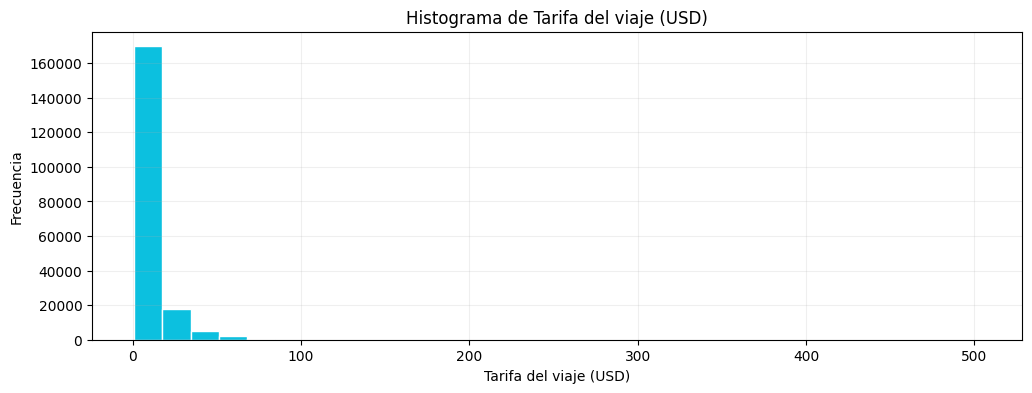

In [19]:
plt.figure(figsize=(12, 4))
data["fare_amount"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Tarifa del viaje (USD)")
plt.xlabel("Tarifa del viaje (USD)")
plt.ylabel("Frecuencia")
plt.show()

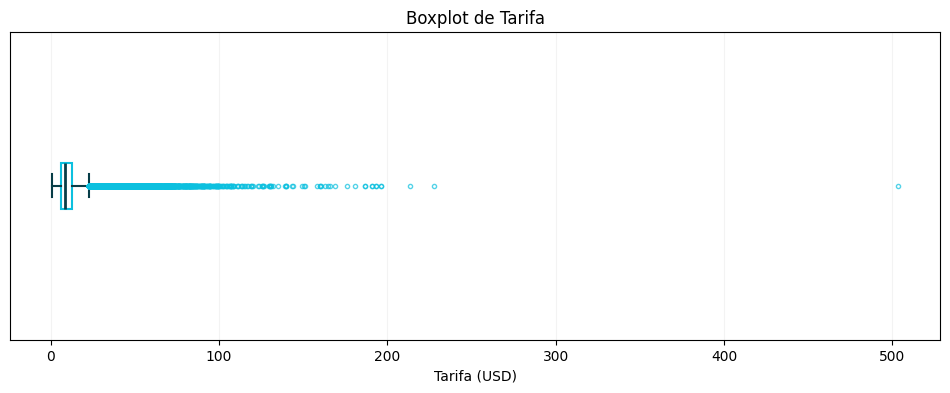

In [20]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["fare_amount"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", linewidth=1.5),
    medianprops=dict(color="#073D47", linewidth=2),
    whiskerprops=dict(color="#073D47", linewidth=1.5),
    capprops=dict(color="#073D47", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markeredgewidth=1,
        markersize=3,
        alpha=0.7
    )
)

plt.title("Boxplot de Tarifa")
plt.xlabel("Tarifa (USD)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.show()

In [21]:
data["fare_amount"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    195173.000000
mean         11.351422
std           9.854040
min           1.000000
1%            2.980000
5%            3.950000
25%           5.980000
50%           8.430000
75%          12.660000
95%          30.230000
99%          53.880000
max         503.130000
Name: fare_amount, dtype: float64

El boxplot de 'fare_amount' deja ver bastante bien que la mayoría de las tarifas se mueve en un rango bajo: la mediana es de 8.43 USD y el 75% de los viajes no pasa de 12.66 USD. Aun así, hay una cola superior bastante marcada, porque mientras el percentil 99 llega a 53.88 USD, el máximo se dispara hasta 503.13 USD. Esto sugiere que hay valores extremos que se alejan bastante del comportamiento general de la variable y que podrían ser atípicos. 

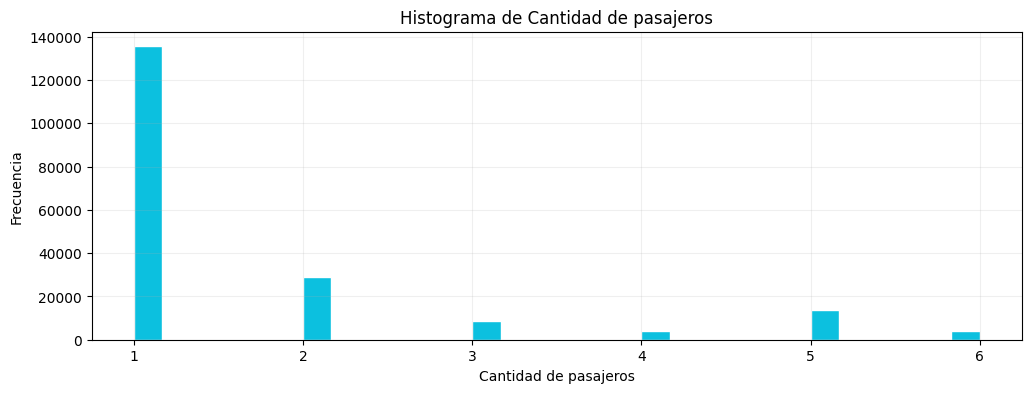

In [22]:
plt.figure(figsize=(12, 4))
data["passenger_count"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Cantidad de pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.show()

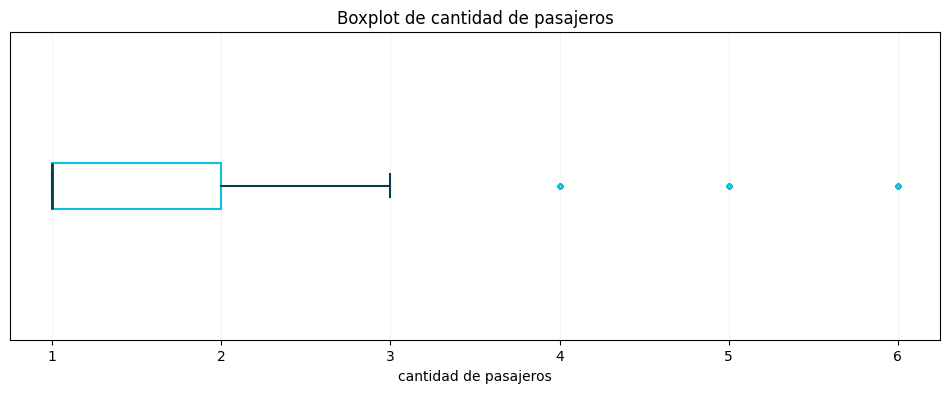

In [23]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["passenger_count"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", linewidth=1.5),
    medianprops=dict(color="#073D47", linewidth=2),
    whiskerprops=dict(color="#073D47", linewidth=1.5),
    capprops=dict(color="#073D47", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markeredgewidth=1,
        markersize=3,
        alpha=0.7
    )
)

plt.title("Boxplot de cantidad de pasajeros")
plt.xlabel("cantidad de pasajeros")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.show()

In [24]:
data["passenger_count"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    195173.000000
mean          1.689691
std           1.305494
min           1.000000
1%            1.000000
5%            1.000000
25%           1.000000
50%           1.000000
75%           2.000000
95%           5.000000
99%           6.000000
max           6.000000
Name: passenger_count, dtype: float64

Similar a lo que se ve antes, en este boxplot es claro cómo la mayor cantidad de los viajes son de un único pasajero o dos, mientras que los viajes de más de tres pasajeros son algo más excepcional, representando menos del 25%

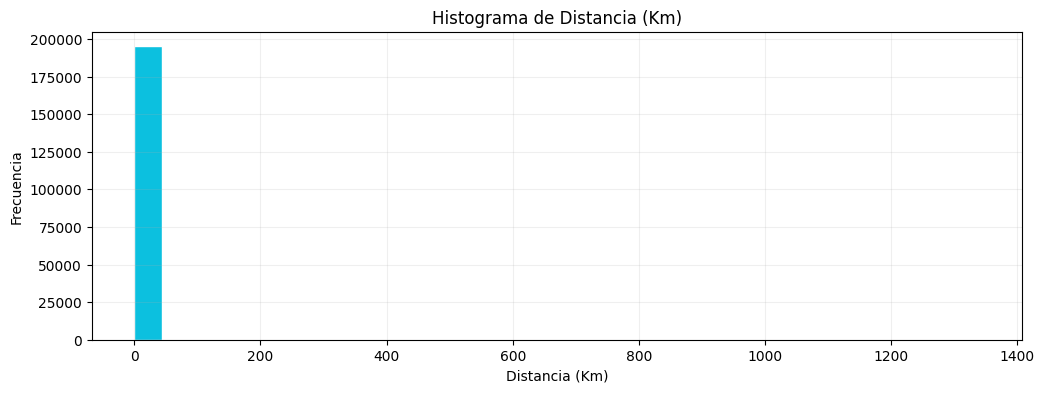

In [25]:
plt.figure(figsize=(12, 4))
data["distance_km"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Distancia (Km)")
plt.xlabel("Distancia (Km)")
plt.ylabel("Frecuencia")
plt.show()

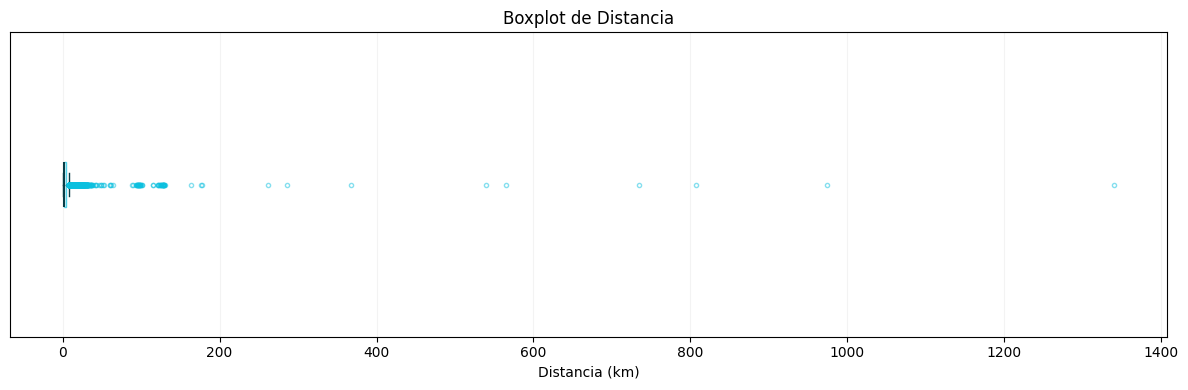

In [26]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["distance_km"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", alpha=0.7),
    medianprops=dict(color="#073D47", linewidth=1.5),
    whiskerprops=dict(color="#073D47"),
    capprops=dict(color="#073D47"),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markersize=3,
        alpha=0.5
    )
)

plt.title("Boxplot de Distancia")
plt.xlabel("Distancia (km)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

In [27]:
data["distance_km"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    195173.000000
mean          3.376782
std           6.391574
min           0.000000
1%            0.000000
5%            0.561803
25%           1.255903
50%           2.157198
75%           3.909870
95%          10.022799
99%          20.401307
max        1340.106401
Name: distance_km, dtype: float64

En distance_km pasa algo parecido, pero todavía más marcado. La mediana es de 2.16 km y el 75% no supera los 3.91 km, así que la mayoría son trayectos cortos. Sin embargo, aparecen algunos valores muy alejados del resto: el percentil 99 está en 20.40 km, pero el máximo llega a 1340.11 km. Eso muestra una distribución muy sesgada hacia la derecha y la presencia de observaciones extremas que después va a ser importante revisar.

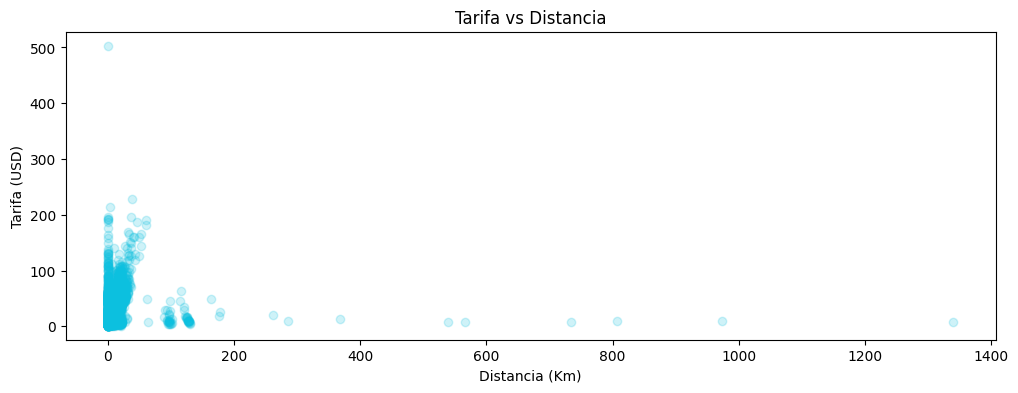

In [28]:
plt.figure(figsize=(12, 4))
plt.scatter(data["distance_km"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Distancia")
plt.xlabel("Distancia (Km)")
plt.ylabel("Tarifa (USD)")
plt.show()

Tanto en los boxplots como en el scatter plot se ve que fare_amount y distance_km tienen valores bastante alejados del comportamiento general. En particular, aparecen viajes muy cortos con tarifas inusualmente altas y también viajes muy largos con tarifas relativamente bajas. Como estos casos pueden influir demasiado en el análisis y en el ajuste del modelo, vamos a tomar los valores por encima del percentil 99.5 como potenciales outliers y los vamos a eliminar en estas variables.

In [29]:
columnas = ["fare_amount", "distance_km"]

for col in columnas:
    limite = data[col].quantile(0.995)
    data = data[data[col] <= limite]

A continuación, se muestran los gráficos una vez aplicado este recorte, para ver con más claridad cómo queda la distribución de los datos.

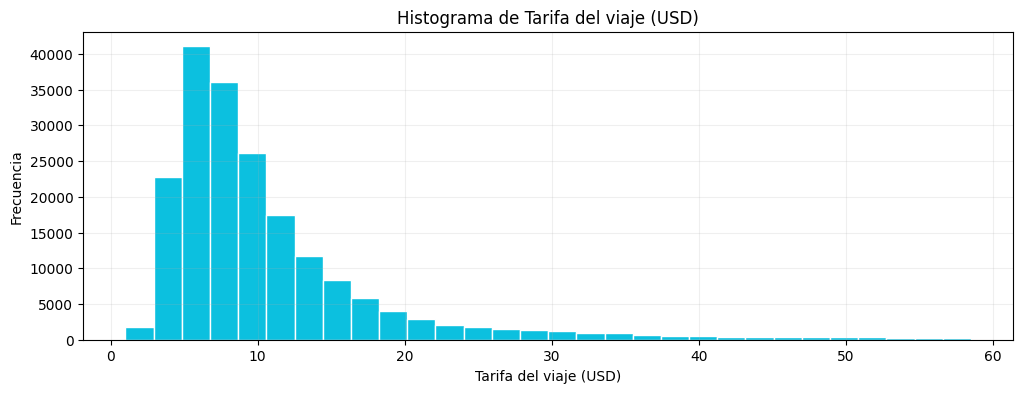

In [30]:
plt.figure(figsize=(12, 4))
data["fare_amount"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Tarifa del viaje (USD)")
plt.xlabel("Tarifa del viaje (USD)")
plt.ylabel("Frecuencia")
plt.show()

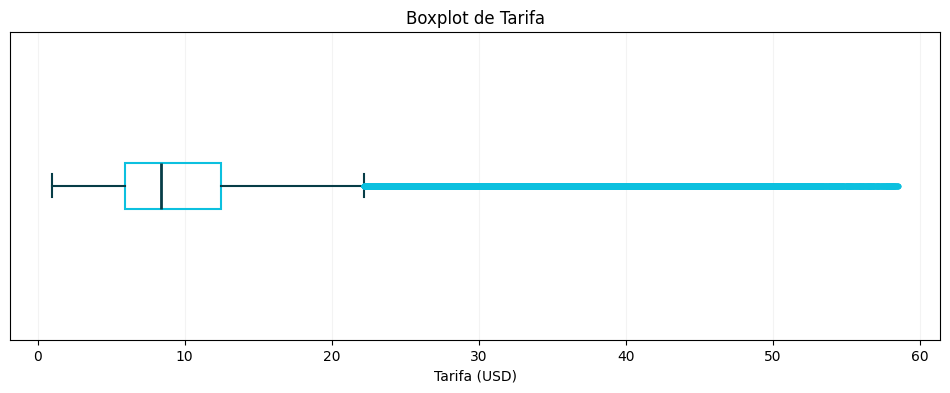

In [31]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["fare_amount"].dropna(),
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", linewidth=1.5),
    medianprops=dict(color="#073D47", linewidth=2),
    whiskerprops=dict(color="#073D47", linewidth=1.5),
    capprops=dict(color="#073D47", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markeredgewidth=1,
        markersize=3,
        alpha=0.7
    )
)

plt.title("Boxplot de Tarifa")
plt.xlabel("Tarifa (USD)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.show()

In [32]:
data["fare_amount"].describe(percentiles=[.25, .50, .75, .95, .99])

count    193226.000000
mean         10.853793
std           8.212946
min           1.000000
25%           5.960000
50%           8.370000
75%          12.460000
95%          27.750000
99%          47.840000
max          58.510000
Name: fare_amount, dtype: float64

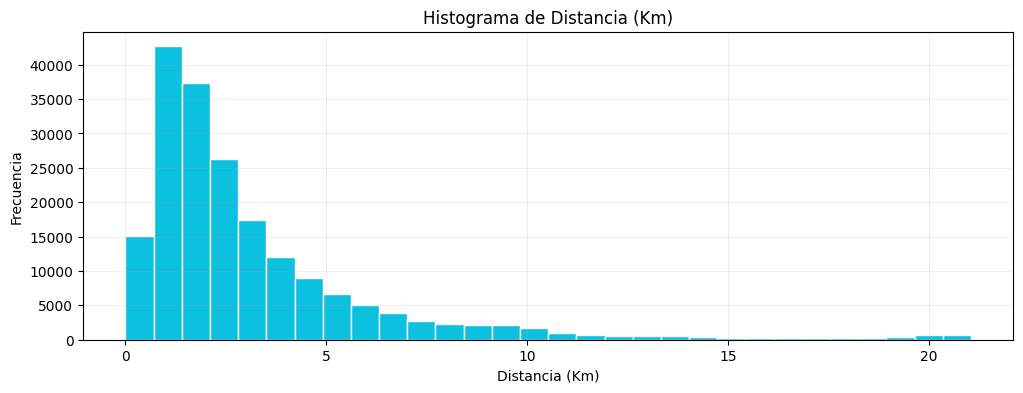

In [33]:
plt.figure(figsize=(12, 4))
data["distance_km"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Distancia (Km)")
plt.xlabel("Distancia (Km)")
plt.ylabel("Frecuencia")
plt.show()

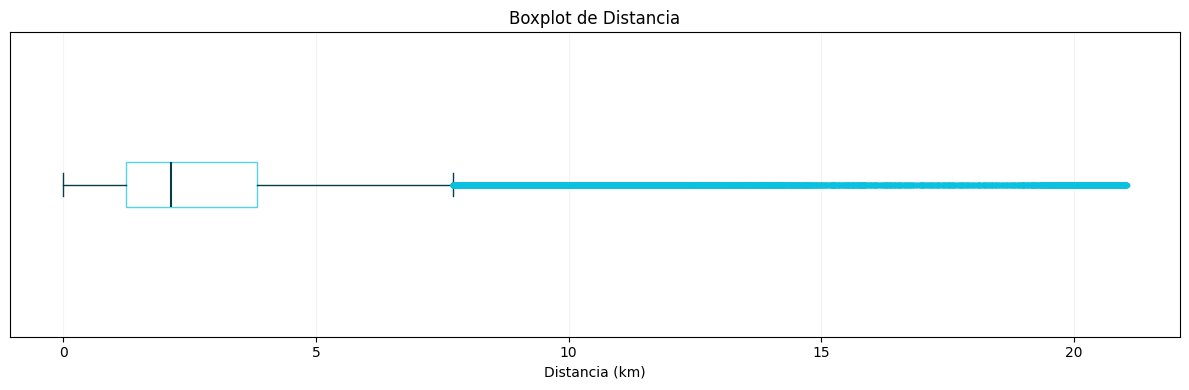

In [34]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["distance_km"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", alpha=0.7),
    medianprops=dict(color="#073D47", linewidth=1.5),
    whiskerprops=dict(color="#073D47"),
    capprops=dict(color="#073D47"),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markersize=3,
        alpha=0.5
    )
)

plt.title("Boxplot de Distancia")
plt.xlabel("Distancia (km)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

In [35]:
data["distance_km"].describe(percentiles=[.25, .50, .75, .95, .99])

count    193226.000000
mean          3.159092
std           3.168786
min           0.000000
25%           1.249703
50%           2.138534
75%           3.833867
95%           9.430818
99%          18.211169
max          21.044396
Name: distance_km, dtype: float64

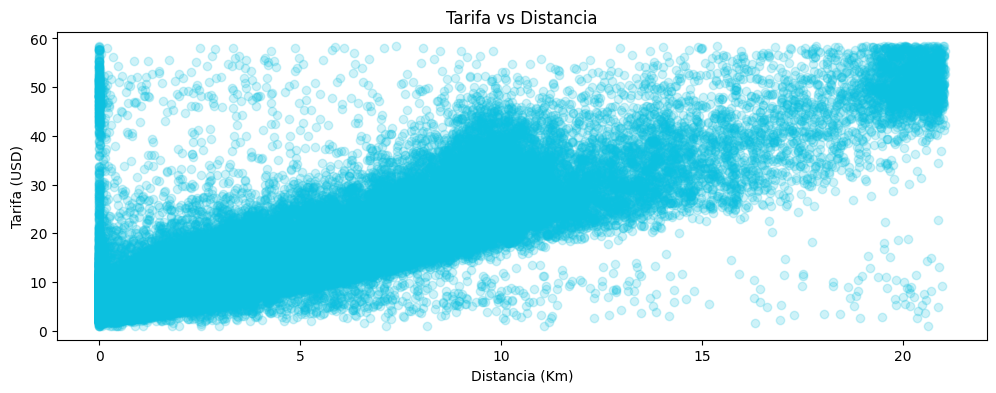

In [36]:
plt.figure(figsize=(12, 4))
plt.scatter(data["distance_km"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Distancia")
plt.xlabel("Distancia (Km)")
plt.ylabel("Tarifa (USD)")
plt.show()

En general, después del recorte los datos quedan bastante más ordenados y fáciles de interpretar. Se reduce la presencia de valores extremos que distorsionaban la visualización y algunas métricas descriptivas, pero se conserva la forma general de las distribuciones. Esto hace que el conjunto de datos resulte más adecuado para las etapas que siguen del trabajo.

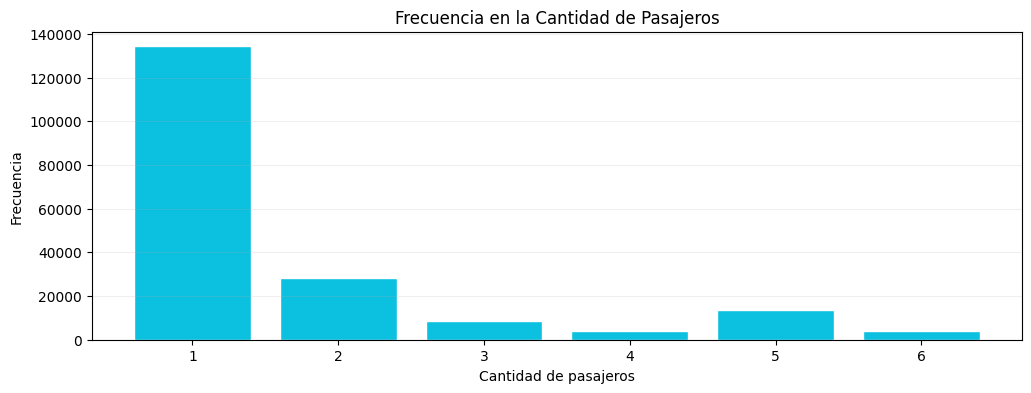

In [37]:
conteo = data["passenger_count"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Frecuencia en la Cantidad de Pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este gráfico podemos ver que hay una fuerte tendencia a los viajes individuales.

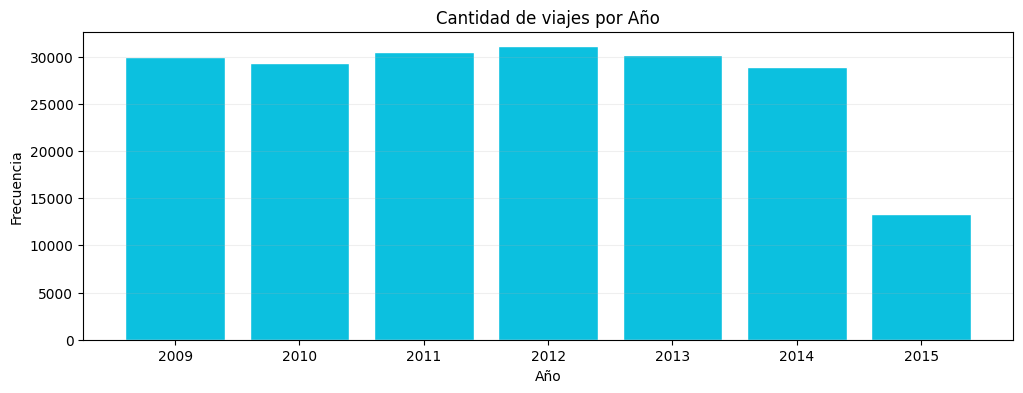

In [38]:
conteo = data["year"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por Año")
plt.xlabel("Año")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

El dataset contiene información hasta mediados del 2015, por lo que para las evaluaciones correspondientes a los meses vamos a usar una copia del dataset que solo tome hasta 2014, así evitamos distribuciones sesgadas por la falta de datos. 

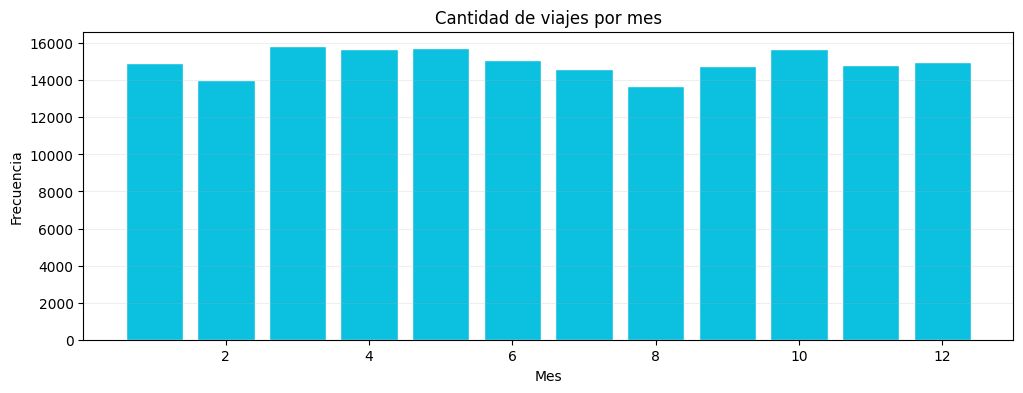

In [39]:
data_2014 = data[data["year"] < 2015].copy()

conteo = data_2014["month"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por mes")
plt.xlabel("Mes")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este gráfico se ve que la cantidad de viajes no se mantiene igual a lo largo del año, sino que va cambiando según el mes. Hay meses en los que la frecuencia sube y otros en los que baja, lo que nos da la idea de que puede haber cierta estacionalidad en los datos. De todas formas, con esta visualización sola no podemos asegurar a qué se debe esa variación, aunque sí nos permite ver que el mes podría estar capturando algún patrón temporal interesante dentro del comportamiento de los viajes.

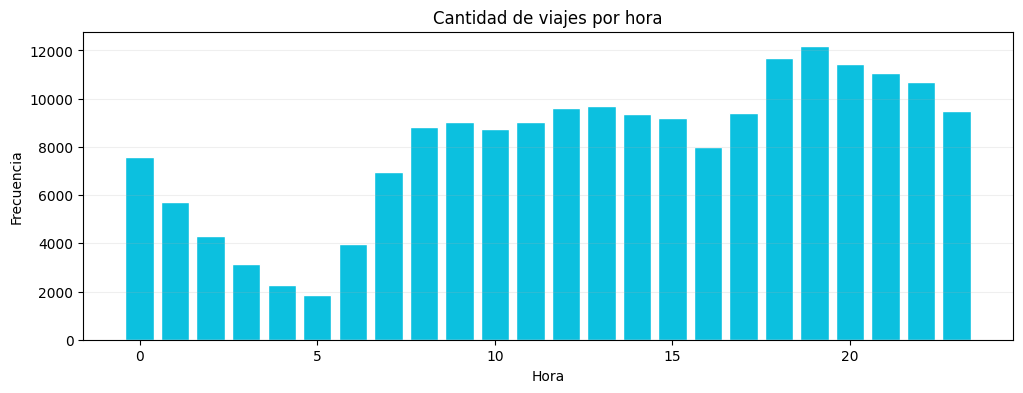

In [40]:
conteo = data["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por hora")
plt.xlabel("Hora")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este gráfico nos muestra que durante la madrugada hay menos viajes, sobre todo entre las 3 y las 6 de la mañana. A partir de ahí la cantidad empieza a subir y se mantiene alta durante buena parte del día, con un pico más marcado hacia la tarde-noche, cerca de las 19 y 20 horas. Esto nos da la idea de que la demanda de viajes cambia según la hora, y que 'hour' puede ser una variable importante para el análisis.

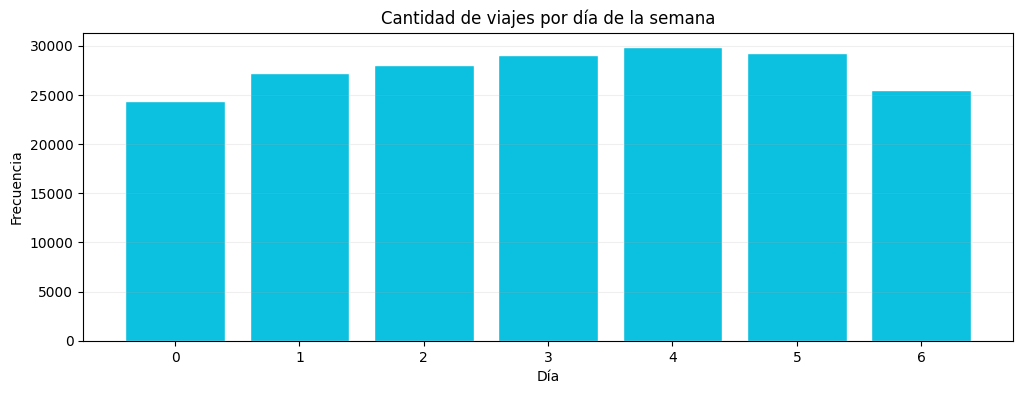

In [41]:
conteo = data["weekday"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por día de la semana")
plt.xlabel("Día")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este caso vemos que si bien los Lunes (Día 0) hay una frecuencia menor, la cantidad de viajes por día se mantiene mayormente estable. 

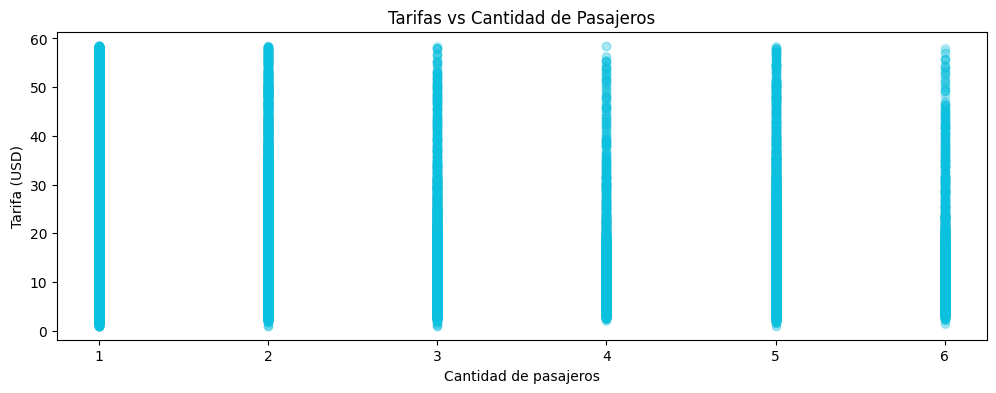

In [42]:
plt.figure(figsize=(12, 4))
plt.scatter(data["passenger_count"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifas vs Cantidad de Pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Tarifa (USD)")
plt.show()

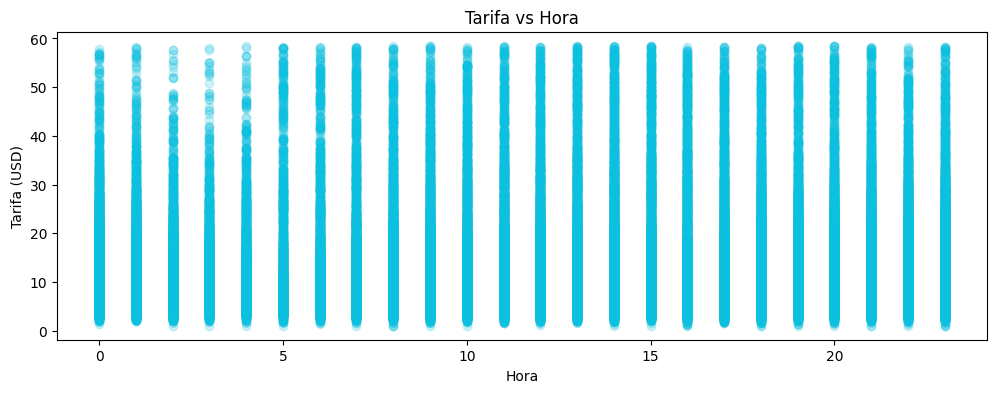

In [43]:
plt.figure(figsize=(12, 4))
plt.scatter(data["hour"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Hora")
plt.xlabel("Hora")
plt.ylabel("Tarifa (USD)")
plt.show()

En estos gráficos no se observa una relación clara entre la cantidad de pasajeros o la hora a la que se realizó el viaje con la tarifa. 

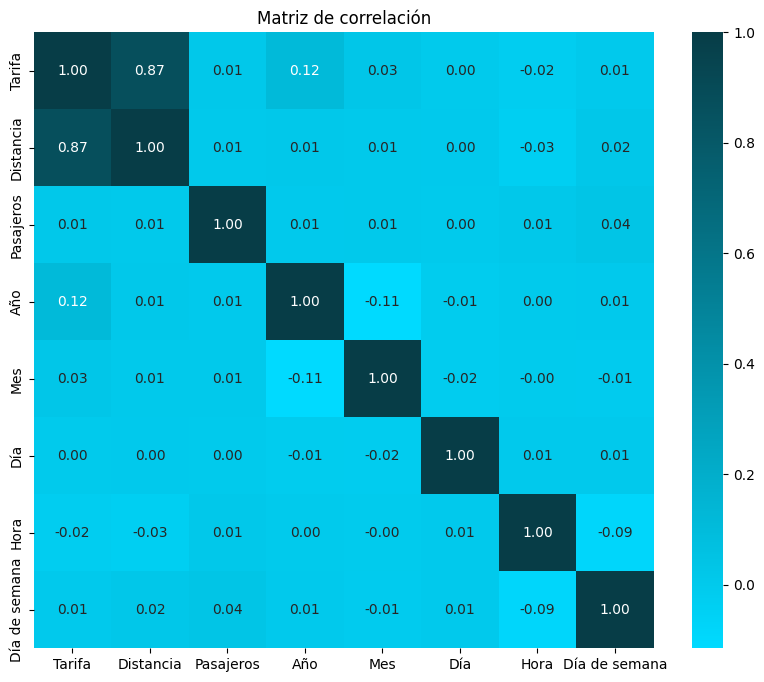

In [44]:
corr_cols = [
    "fare_amount",
    "distance_km",
    "passenger_count",
    "year",
    "month",
    "day",
    "hour",
    "weekday"
]

corr = data[corr_cols].corr(numeric_only=True)

nombres = {
    "fare_amount": "Tarifa",
    "distance_km": "Distancia",
    "passenger_count": "Pasajeros",
    "year": "Año",
    "month": "Mes",
    "day": "Día",
    "hour": "Hora",
    "weekday": "Día de semana"
}

corr = corr.rename(index=nombres, columns=nombres)

cmap_personalizado = LinearSegmentedColormap.from_list(
    "mi_cmap",
    ["#00daff", "#073D47"]
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap=cmap_personalizado, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

En la matriz de correlación se ve bastante claro que la variable con mayor relación lineal con la tarifa es la distancia, con una correlación alta y positiva. Esto era esperable, ya que a mayor distancia recorrida, mayor tiende a ser el costo del viaje. En cambio, el resto de las variables muestran correlaciones bastante bajas con la tarifa, por lo que, al menos de manera lineal, no parecen tener un peso tan fuerte por sí solas.

In [45]:
print(data.shape)

(193226, 14)


A lo largo del análisis detectamos valores faltantes (en dropoff), cantidades de pasajeros no lógicas (0 o 208), coordenadas inexistentes o fuera del rango de interés y algunos valores extremos que podían sumar ruido en variables importantes como la tarifa y la distancia. 

Después de aplicar esta limpieza, pasamos de 200.000 registros a 193.226, es decir, se eliminaron 6.774 filas, que representan alrededor del 3,39% del total. Esto nos deja una base bastante más consistente para seguir trabajando, sin haber perdido una parte grande de la información original.

A su vez, los gráficos y las medidas descriptivas posteriores al recorte nos permiten ver los datos de una forma mucho más clara, y la matriz de correlación termina de resumir qué variables parecen estar más vinculadas con la tarifa. 

Con todo esto, el conjunto de datos final es más consistente y está correctamente preparado para avanzar con la parte de modelado.

# Codificación de variables  
se opta por codificar mediante one-hot las variables de mes, hora y día de semana para que el modelo no interprete que hay alguna relación ordinal entre ellas.

In [46]:
modelo = data.drop(columns = ["key","timezone","day"])
x = modelo.drop(columns = ["fare_amount"])
y = modelo["fare_amount"]

In [47]:
modelo.columns

Index(['fare_amount', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'year',
       'month', 'hour', 'weekday', 'distance_km'],
      dtype='str')

Se toma la decisión de crear un dataframe nuevo con las variables a utilizar para el modelado. Se consideran cómo predictores todas las variables menos key, ya que no tiene relación alguna con los viajes en sí, a timezone, es identica en todos los casos, no tiene sentido para este analisis y a day, ya que se considera que es una variable que no va a aportar tanto a la predicción y al codificarla creará una cantidad muy grande de columnas para identificar que número del día del mes fué el viaje 

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=66)

print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (154580, 10)
X_test : (38646, 10)
y_train: (154580,)
y_test : (38646,)


se realiza el split train/test con un test del 20% de los datos.

In [49]:
x_train = pd.get_dummies(x_train, columns=["month", "weekday", "hour"], drop_first=True)
x_test  = pd.get_dummies(x_test,  columns=["month", "weekday", "hour"], drop_first=True)

x_train, x_test = x_train.align(x_test, join="left", axis=1, fill_value=0)

se hacen los dummies de las variables categoricas

In [50]:
scaler = StandardScaler()

x_train_escalado = scaler.fit_transform(x_train)
x_test_escalado = scaler.transform(x_test)

print(x_train_escalado.shape)
print(x_test_escalado.shape)

(154580, 47)
(38646, 47)


Luego del análisis descriptivo se eliminaron registros faltantes e inconsistentes, se trataron outliers y se construyó una variable derivada relevante para el problema. A partir de la matriz de correlación y los gráficos exploratorios, se observó que la distancia presenta la asociación más clara con la tarifa, mientras que otras variables aportan información complementaria pero, a simple vista, no tan decisiva con respecto a la variable target. Finalmente, se definieron las variables predictoras, se dividió el dataset en entrenamiento y prueba, se codificaron las variables categóricas y se escalaron los datos.

In [51]:
# funciones auxiliares
def calcular_metricas(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    }

def resumen_metricas(nombre_modelo, y_train, y_pred_train, y_test, y_pred_test):
    metricas_train = calcular_metricas(y_train, y_pred_train)
    metricas_test = calcular_metricas(y_test, y_pred_test)

    resumen = pd.DataFrame({
        "Train": metricas_train,
        "Test": metricas_test
    })

    print(f"Métricas del modelo: {nombre_modelo}")
    return resumen

def grafico_residuos(y_true, y_pred, titulo):
    residuos = y_true - y_pred

    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuos, alpha=0.3)
    plt.axhline(y=0, color="red", linestyle="--")
    plt.title(titulo)
    plt.xlabel("Valores predichos")
    plt.ylabel("Residuos")
    plt.grid(alpha=0.2)
    plt.show()

Se definen las funciones auxiliares que se usaran para evaluar los diferentes modelos.

In [52]:
modelo_lr = LinearRegression()
modelo_lr.fit(x_train_escalado, y_train)

y_pred_train_lr = modelo_lr.predict(x_train_escalado)
y_pred_test_lr = modelo_lr.predict(x_test_escalado)

print("Intercepto:")
print(modelo_lr.intercept_)

tabla_metricas_lr = resumen_metricas(
    "Regresión Lineal Múltiple",
    y_train,
    y_pred_train_lr,
    y_test,
    y_pred_test_lr
)

tabla_metricas_lr

Intercepto:
10.852114245051055
Métricas del modelo: Regresión Lineal Múltiple


,Train,Test
R2,0.778012,0.782317
MSE,14.967212,14.708153
RMSE,3.868748,3.835121
MAE,2.193354,2.183219


El modelo de regresión lineal múltiple obtuvo valores de R^2 cercanos a 0.78 tanto en entrenamiento como en prueba, con lo que vemos una buena capacidad de explicar la variabilidad de los datos. Las métricas de error son muy similares entre ambos conjuntos, lo que sugiere una buena capacidad de generalización y ausencia de sobreajuste marcado.

In [53]:
coeficientes_lr = pd.DataFrame({
    "Variable": x_train.columns,
    "Coeficiente": modelo_lr.coef_
}).sort_values(by="Coeficiente", key=np.abs, ascending=False)

coeficientes_lr.head(15)

,Variable,Coeficiente
6,distance_km,6.951478
5,year,0.883384
3,dropoff_latitude,-0.507940
0,pickup_longitude,0.457170
37,hour_14,0.275137
35,hour_12,0.273036
38,hour_15,0.261963
36,hour_13,0.260314
34,hour_11,0.244493
40,hour_17,0.236564


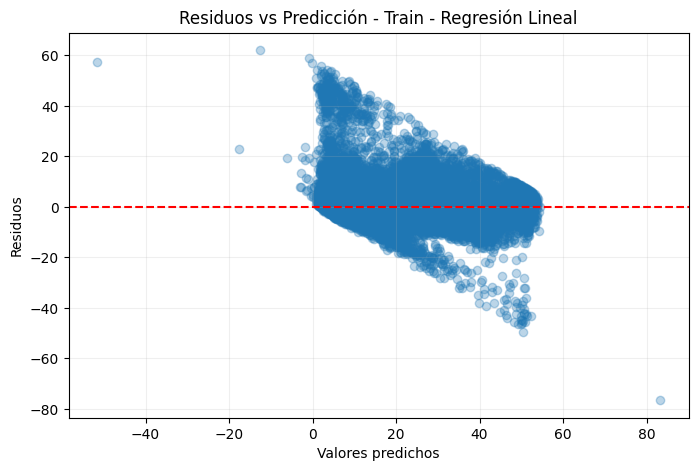

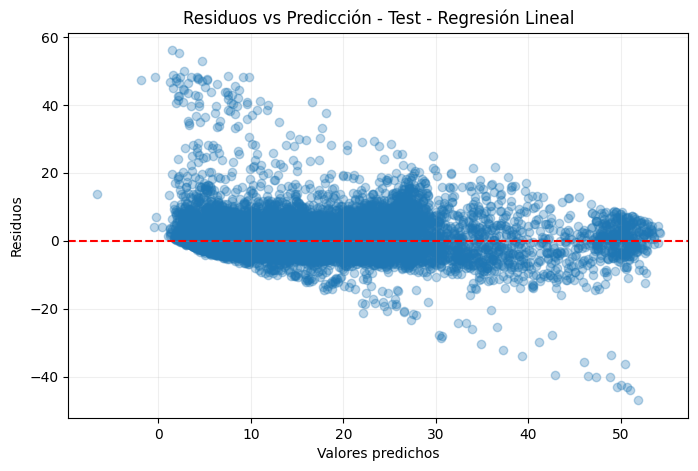

In [54]:
grafico_residuos(
    y_train,
    y_pred_train_lr,
    "Residuos vs Predicción - Train - Regresión Lineal"
)

grafico_residuos(
    y_test,
    y_pred_test_lr,
    "Residuos vs Predicción - Test - Regresión Lineal"
)

Los gráficos de residuos indican que el modelo lineal presenta un ajuste razonable, pero no perfecto. Si bien los errores se mantienen en torno a cero y las métricas son estables entre entrenamiento y prueba, se observa un patrón con forma descendente en los extremos dónde el modelo sobreestima los viajes de menor valor y subestima los viajes largos, lo que sugiere que no logra explicar completamente toda la variabilidad de los datos, lo cuál tiene sentido ya que de los datos disponibles nos faltan variables que también influyen en los precios, tales cómo demanda, clima en el viaje, tipo de zona, trafico, entre otras.

In [55]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    shapes:
        X_train = nxm
        y_train = nx1
        X_val = pxm
        y_val = px1
        W_gd = mx1
    """
    
    n = X_train.shape[0]
    m = X_train.shape[1]
    o = X_val.shape[0]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))

    W_gd = np.random.randn(m + 1).reshape(m + 1, 1)

    train_errors = []
    test_errors = []

    for _ in range(epochs):
        prediction_train = np.matmul(X_train, W_gd)
        error_train = y_train - prediction_train
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        prediction_test = np.matmul(X_val, W_gd)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2 / n * grad_sum
        gradient = np.transpose(grad_mul).reshape(-1, 1)

        W_gd = W_gd - (lr * gradient)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de validación')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    plt.show()

    return W_gd, train_errors, test_errors

In [ ]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train_bias = np.hstack((np.ones((n, 1)), X_train))
    X_test_bias = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W_sgd = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_train_shuffled = X_train_bias[permutation]
        y_train_shuffled = y_train[permutation]

        for j in range(n):
            x_sample = X_train_shuffled[j].reshape(1, -1)
            y_sample = y_train_shuffled[j].reshape(1, 1)

            prediction = np.matmul(x_sample, W_sgd)
            error = y_sample - prediction

            gradient = -2 * np.matmul(x_sample.T, error)
            W_sgd = W_sgd - (lr * gradient)

        prediction_train = np.matmul(X_train_bias, W_sgd)
        error_train = y_train - prediction_train
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        prediction_test = np.matmul(X_test_bias, W_sgd)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.ylim(0, 100)  # pequeña trampilla hecha para que los graficos no se ensucien
    plt.show()
    
    return W_sgd, train_errors, test_errors

# Optimización de la implementación de SGD  

La versión inicial del descenso por gradiente estocástico presentaba un problema de rendimiento importante, ya que dentro del ciclo interno, es decir, en cada actualización hecha con una sola muestra, se recalculaba también el error sobre todo el conjunto de prueba. Esto implicaba un costo computacional muy alto, porque por cada época no solo se recorría el conjunto de entrenamiento muestra por muestra, sino que además se volvía a predecir sobre todo el conjunto de prueba miles de veces. La primera iteración usando el código dado en clase tardó 210 minutos en ejecutarse.  

Para corregir esto, se mantuvo la lógica propia de Stochastic Gradient Descent, es decir, la actualización de los pesos muestra por muestra, pero se modificó el cálculo de las métricas:  

el ajuste de los pesos sigue haciéndose de manera estocástica, una observación a la vez;  
el error de entrenamiento y el error de prueba pasan a calcularse una vez por época y no una vez por muestra;  
de esta forma, se reduce drásticamente el tiempo de ejecución y se obtienen curvas de error más limpias y comparables.  

Además, se realizó una mejora en la manipulación de los datos dentro del algoritmo:  

en lugar de sobrescribir directamente X_train, se trabaja con una versión mezclada (X_train_shuffled) en cada época;  
cada muestra se reacomoda explícitamente con reshape(1, -1) para mantener consistencia matricial al calcular la predicción y el gradiente.

In [ ]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W_mbgd = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W_mbgd)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W_mbgd = W_mbgd - (lr * gradient)

            prediction_test = np.matmul(X_test, W_mbgd)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.ylim(0, 100)  # pequeña trampilla hecha para que los graficos no se ensucien tanto
    plt.show()

    return W_mbgd, train_errors, test_errors

Se definen los tres métodos de descenso por gradiente  
Pequeña aclaración de código: se puso un tope vertical de MSE 100, porque al ejecuar los programas sucedió de que al tener valores de MSE muy altos para algunas itereaciones las gráficas quedaban cómo lineas con salto de hasta 25 000. Se optó por el límite vertical de 100 porque creemos que permite ver la variabilidad de datos más claramente.

In [58]:
X_train_gd, X_val_gd, y_train_gd, y_val_gd = train_test_split(
    x_train_escalado,
    y_train,
    test_size=0.125,
    random_state=42
)

y_train_gd = np.array(y_train_gd).reshape(-1, 1)
y_val_gd = np.array(y_val_gd).reshape(-1, 1)
y_test_gd = np.array(y_test).reshape(-1, 1)

X_train_gd = np.array(X_train_gd)
X_val_gd = np.array(X_val_gd)
X_test_gd = np.array(x_test_escalado)

print(X_train_gd.shape, y_train_gd.shape)
print(X_val_gd.shape, y_val_gd.shape)
print(X_test_gd.shape, y_test_gd.shape)

(135257, 47) (135257, 1)
(19323, 47) (19323, 1)
(38646, 47) (38646, 1)


Se separan los datos de modelo en train y validación y luego se les da la forma necesaria para las operaciones matriciales.

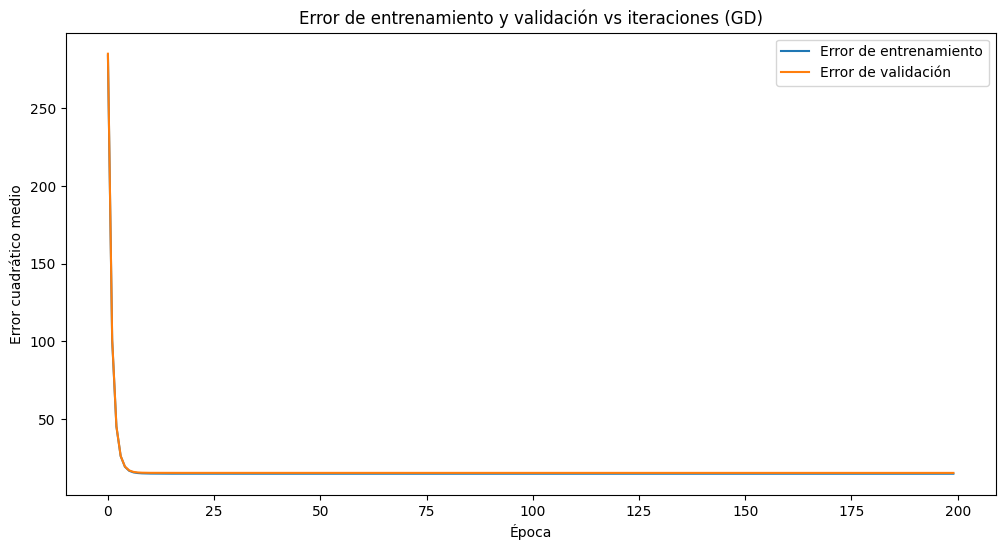

lr = 0.2
Mejor validation MSE: 15.43266722915955
Mejor época: 200
----------------------------------------


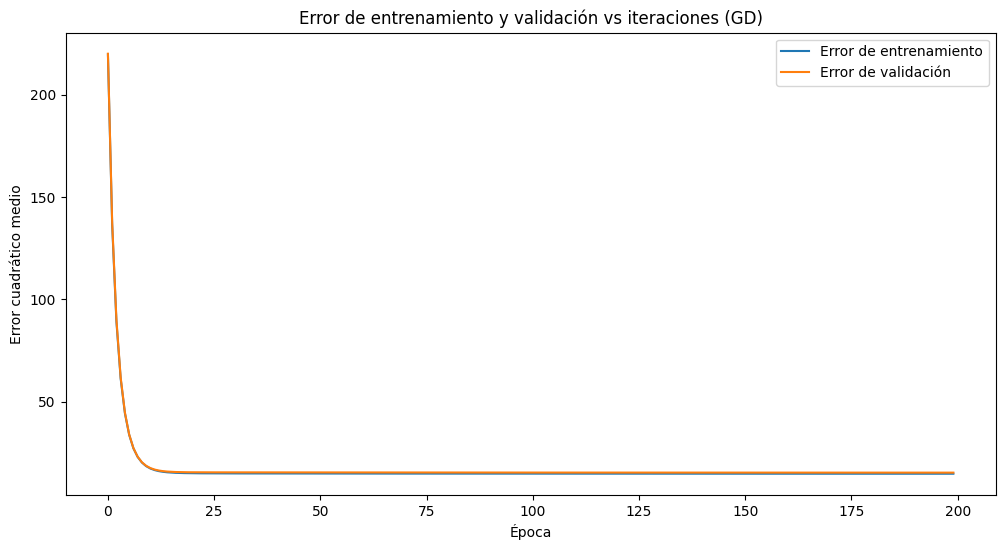

lr = 0.1
Mejor validation MSE: 15.442228019298097
Mejor época: 200
----------------------------------------


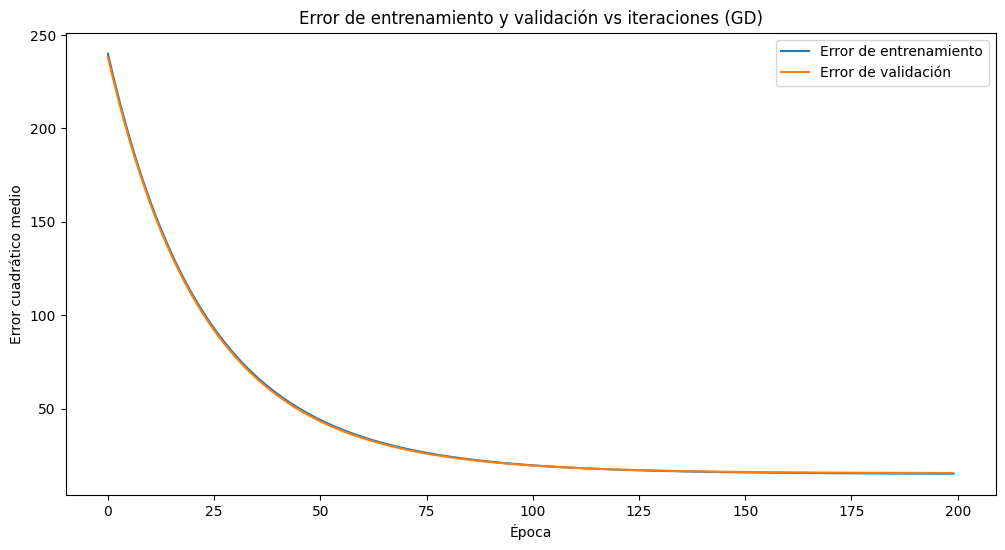

lr = 0.01
Mejor validation MSE: 15.542091772145916
Mejor época: 200
----------------------------------------


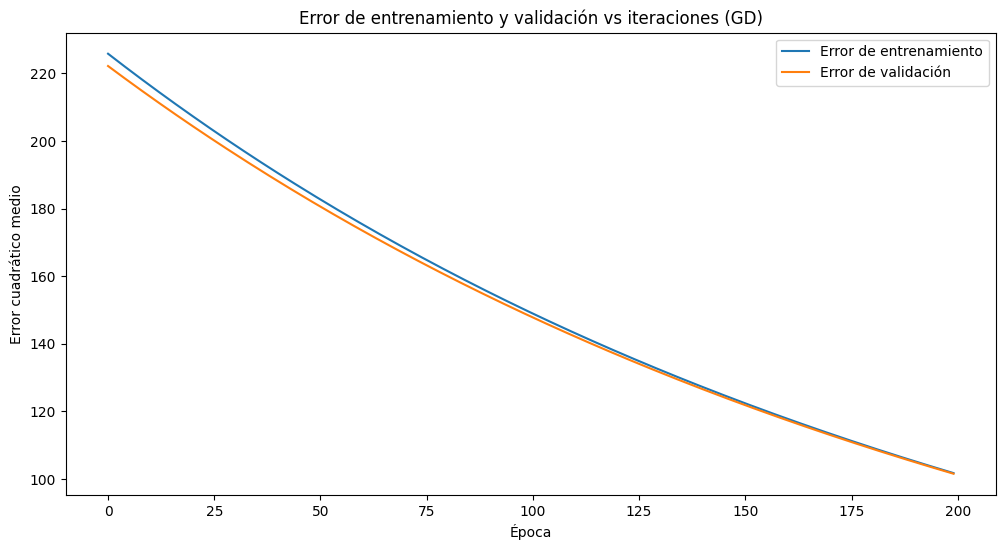

lr = 0.001
Mejor validation MSE: 101.55120560242074
Mejor época: 200
----------------------------------------


In [59]:
lrs = [0.2, 0.1, 0.01, 0.001]
resultados_gd = {}

for lr in lrs:
    W_gd, train_errors, val_errors = gradient_descent(
        X_train_gd, y_train_gd,
        X_val_gd, y_val_gd,
        lr=lr,
        epochs=200
    )

    resultados_gd[lr] = {
        "W_gd": W_gd,
        "train_errors": train_errors,
        "val_errors": val_errors,
        "mejor_val_mse": min(val_errors),
        "mejor_epoch": np.argmin(val_errors) + 1
    }

    print(f"lr = {lr}")
    print(f"Mejor validation MSE: {min(val_errors)}")
    print(f"Mejor época: {np.argmin(val_errors) + 1}")
    print("-" * 40)

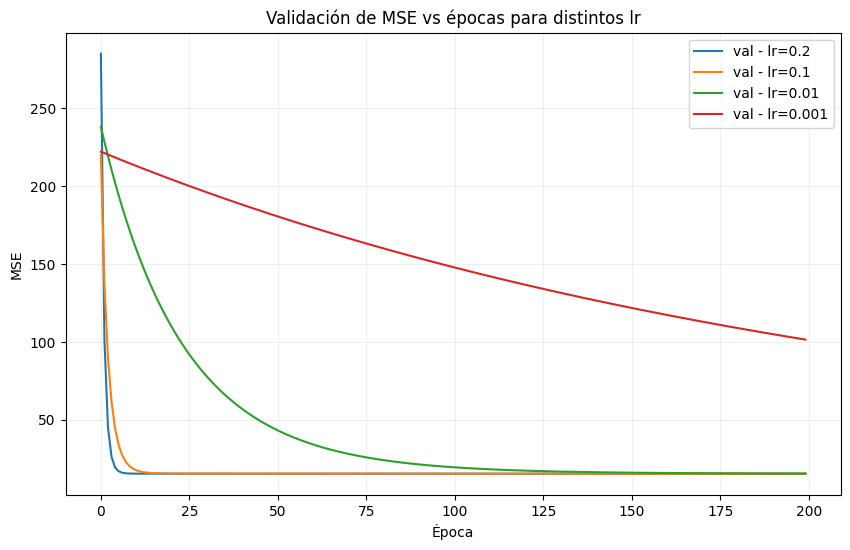

In [60]:
plt.figure(figsize=(10, 6))

for lr in lrs:
    plt.plot(resultados_gd[lr]["val_errors"], label=f"val - lr={lr}")

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Validación de MSE vs épocas para distintos lr")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Se observa una rápida convergencia con learning rates altos mientras que con lr más bajos se puede ver cómo tarda muchas más épocas en alcanzar un punto estable similar. Se define que el mejor resultado es con lr = 0.2 y epochs = 25

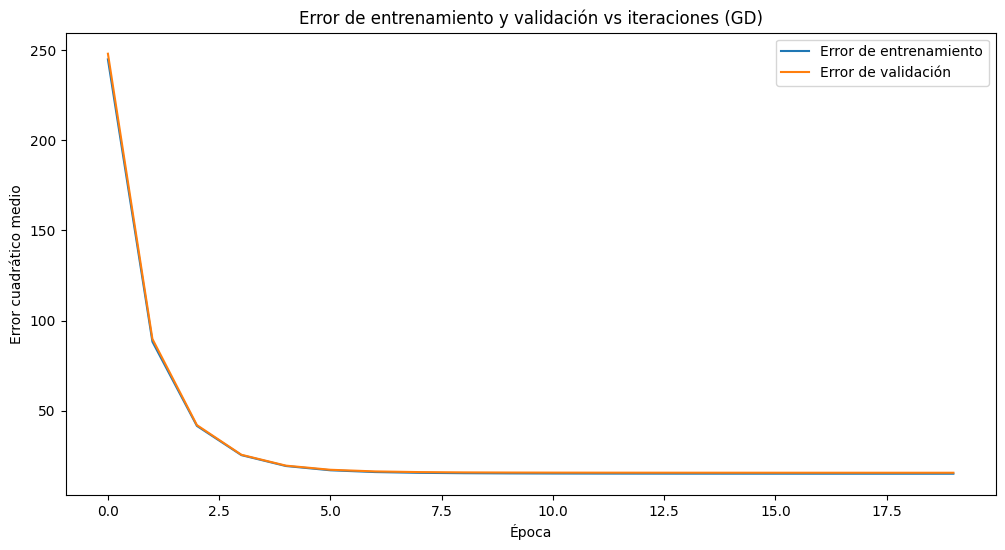

In [61]:
W_gd, train_errors_gd, val_errors_gd = gradient_descent(
    X_train_gd, y_train_gd,
    X_val_gd, y_val_gd,
    lr=0.2,
    epochs=20)

In [62]:
X_train_gd_bias = np.hstack((np.ones((X_train_gd.shape[0], 1)), X_train_gd))
X_test_gd_bias = np.hstack((np.ones((X_test_gd.shape[0], 1)), X_test_gd))

y_pred_train_gd = np.matmul(X_train_gd_bias, W_gd).ravel()
y_pred_test_gd = np.matmul(X_test_gd_bias, W_gd).ravel()

tabla_metricas_gd = resumen_metricas(
    "Gradient Descent",
    y_train_gd.ravel(),
    y_pred_train_gd,
    y_test_gd.ravel(),
    y_pred_test_gd
)

tabla_metricas_gd

Métricas del modelo: Gradient Descent


,Train,Test
R2,0.778102,0.781856
MSE,14.928568,14.739360
RMSE,3.863750,3.839187
MAE,2.193540,2.187765


Se entrena el modelo con los hiperparametros definidos. Se obtiene un R2 parejo entre train y test, con eso concluimos que no estamos teniendo overfitting. Con descenso por gradiente podemos explicar el 78.1% de la variabilidad de los datos, los datos predichos pueden tener un error de 3.8$

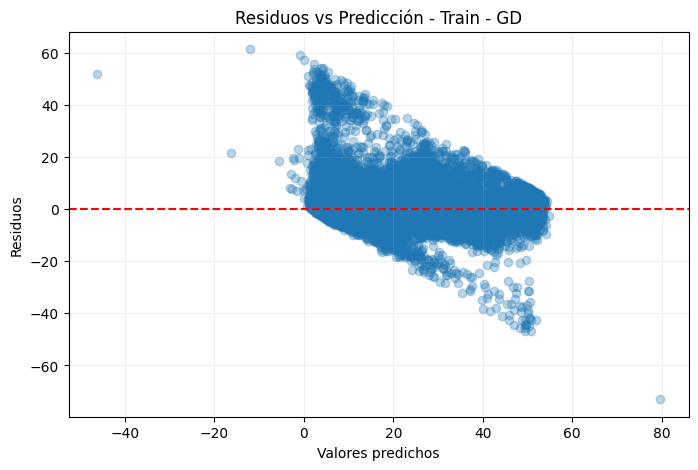

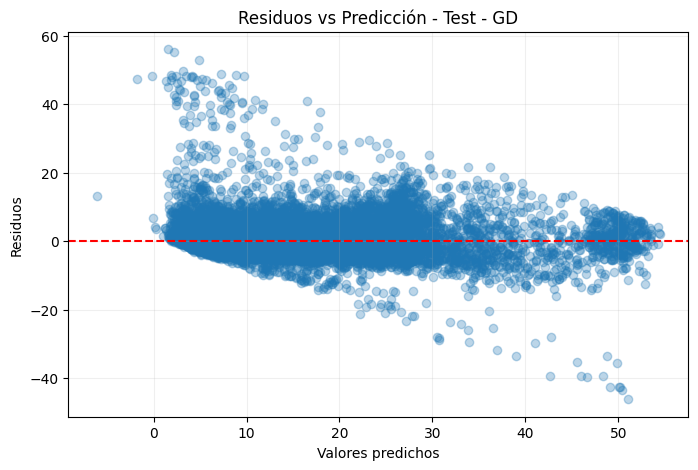

In [63]:
grafico_residuos(
    y_train_gd.ravel(),
    y_pred_train_gd,
    "Residuos vs Predicción - Train - GD"
)

grafico_residuos(
    y_test_gd.ravel(),
    y_pred_test_gd,
    "Residuos vs Predicción - Test - GD"
)

Se aprecian patrones de ruido similares a la regresión lineal, no hay nuevas conclusiones.

C:\Users\sebas\AppData\Local\Temp\ipykernel_23752\2642162469.py:30: RuntimeWarning: overflow encountered in square
  train_mse = np.mean(error_train ** 2)
C:\Users\sebas\AppData\Local\Temp\ipykernel_23752\2642162469.py:35: RuntimeWarning: overflow encountered in square
  test_mse = np.mean(error_test ** 2)
C:\Users\sebas\AppData\Local\Temp\ipykernel_23752\2642162469.py:25: RuntimeWarning: overflow encountered in multiply
  gradient = -2 * np.matmul(x_sample.T, error)
C:\Users\sebas\AppData\Local\Temp\ipykernel_23752\2642162469.py:26: RuntimeWarning: invalid value encountered in subtract
  W_sgd = W_sgd - (lr * gradient)
C:\Users\sebas\AppData\Local\Temp\ipykernel_23752\2642162469.py:22: RuntimeWarning: invalid value encountered in matmul
  prediction = np.matmul(x_sample, W_sgd)


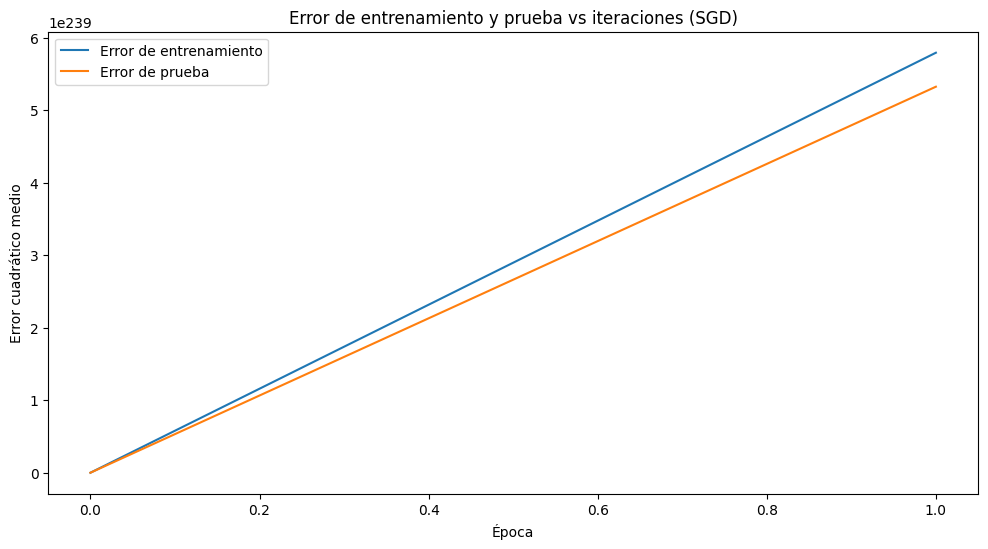

lr = 0.01
Mejor validation MSE: 4.8084597229142784e+126
Mejor época: 6
----------------------------------------


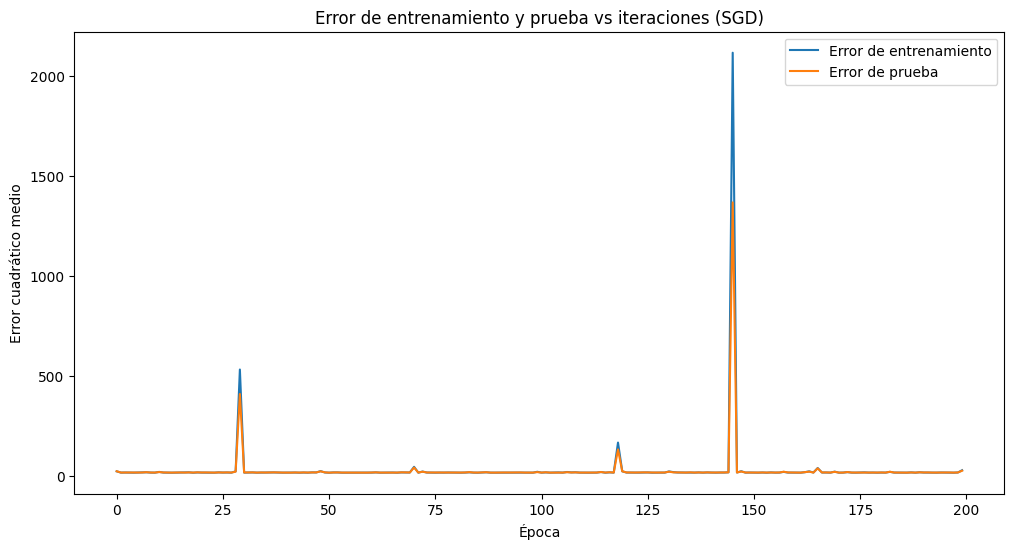

lr = 0.001
Mejor validation MSE: 15.621914399933257
Mejor época: 51
----------------------------------------


KeyboardInterrupt: 

In [64]:
lrs_sgd = [0.01, 0.001, 0.0005]
resultados_sgd = {}

for lr in lrs_sgd:
    W_sgd, train_errors, val_errors = stochastic_gradient_descent(
        X_train_gd, y_train_gd,
        X_val_gd, y_val_gd,
        lr=lr,
        epochs=200
    )

    resultados_sgd[lr] = {
        "W_sgd": W_sgd,
        "train_errors": train_errors,
        "val_errors": val_errors,
        "mejor_val_mse": min(val_errors),
        "mejor_epoch": np.argmin(val_errors) + 1
    }

    print(f"lr = {lr}")
    print(f"Mejor validation MSE: {min(val_errors)}")
    print(f"Mejor época: {np.argmin(val_errors) + 1}")
    print("-" * 40)

El modelo encuentra convergencia de forma casi instantanea con los lr probados menores que 0.01. Se definen cómo parametros lr = 0.001 y epochs = 10

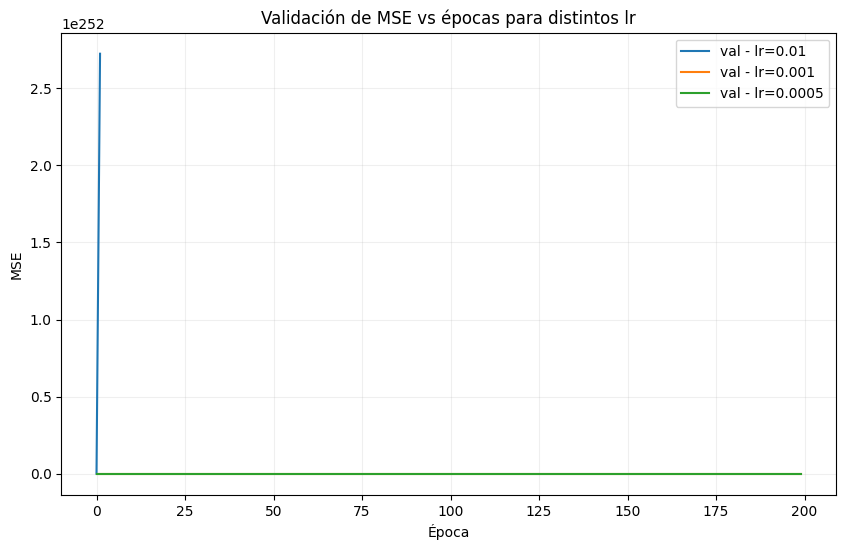

In [ ]:
plt.figure(figsize=(10, 6))

for lr in lrs_sgd:
    plt.plot(resultados_sgd[lr]["val_errors"], label=f"val - lr={lr}")

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Validación de MSE vs épocas para distintos lr")
plt.legend()
plt.grid(alpha=0.2)
plt.ylim(0, 100)  # pequeña trampilla hecha para que los graficos no se ensucien tanto
plt.show()

agregar a la función de plot un límite superior de MSE,  para que no se arruine la vista NOTA

In [ ]:
W_sgd, train_errors_sgd, val_errors_sgd = stochastic_gradient_descent(
    X_train_gd, y_train_gd,
    X_val_gd, y_val_gd,
    lr=0.001,
    epochs=10)

NameError: name 'stochastic_gradient_descent' is not defined

In [ ]:
X_train_sgd_bias = np.hstack((np.ones((X_train_gd.shape[0], 1)), X_train_gd))
X_test_sgd_bias = np.hstack((np.ones((X_test_gd.shape[0], 1)), X_test_gd))

y_pred_train_sgd = np.matmul(X_train_gd_bias, W_sgd).ravel()
y_pred_test_sgd = np.matmul(X_test_gd_bias, W_sgd).ravel()

tabla_metricas_sgd = resumen_metricas(
    "Stochastic Gradient Descent",
    y_train_gd.ravel(),
    y_pred_train_sgd,
    y_test_gd.ravel(),
    y_pred_test_sgd
)

tabla_metricas_sgd

Métricas del modelo: Stochastic Gradient Descent


,Train,Test
R2,0.759747,0.764955
MSE,16.163413,15.881308
RMSE,4.020375,3.985136
MAE,2.400408,2.386318


El modelo de Descenso por Gradiente Estocastico tuvo un rendimiento levemente inferior al de BGD. El modelo explica el 75.6% de las variables, de igual manera, no hay disparidad entre train y test por lo que no se tiene overfitting. Los datos con este modelo pueden alejarse hasta 4usd de los reales.

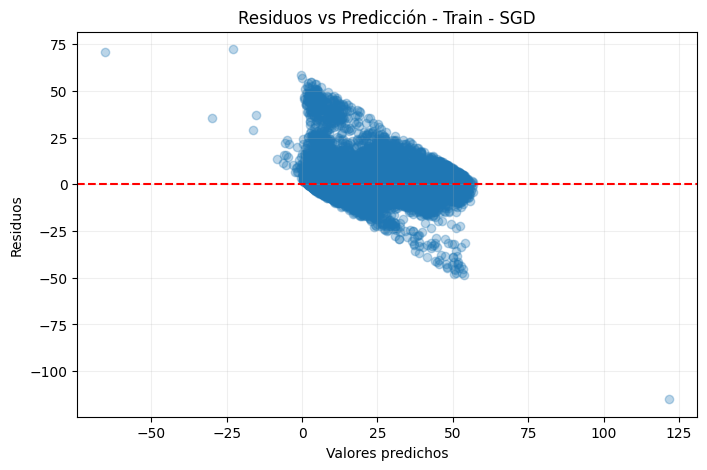

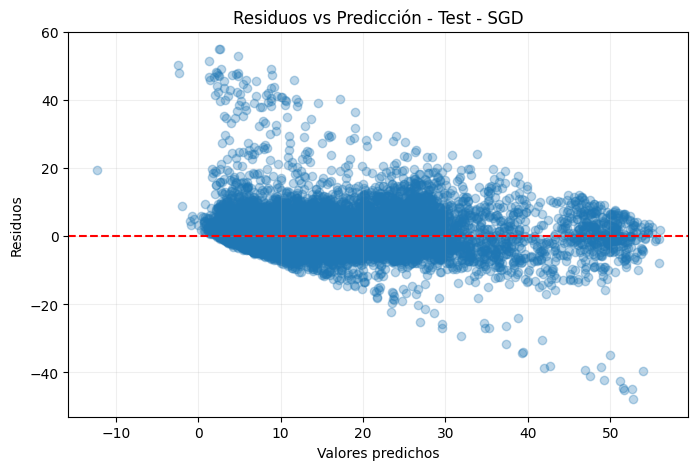

In [ ]:
grafico_residuos(
    y_train_gd.ravel(),
    y_pred_train_sgd,
    "Residuos vs Predicción - Train - SGD"
)

grafico_residuos(
    y_test_gd.ravel(),
    y_pred_test_sgd,
    "Residuos vs Predicción - Test - SGD"
)

Del grafico de ruido se observa el mismo fenómeno que se ve en regreseion lineal y en descenso por gradiente por lote, que es que en mayoría de los casos la función generaliza bien pero hay un sesgo en parte de los datos que se atribuye a variables desconocidas por el set de datos disponible.

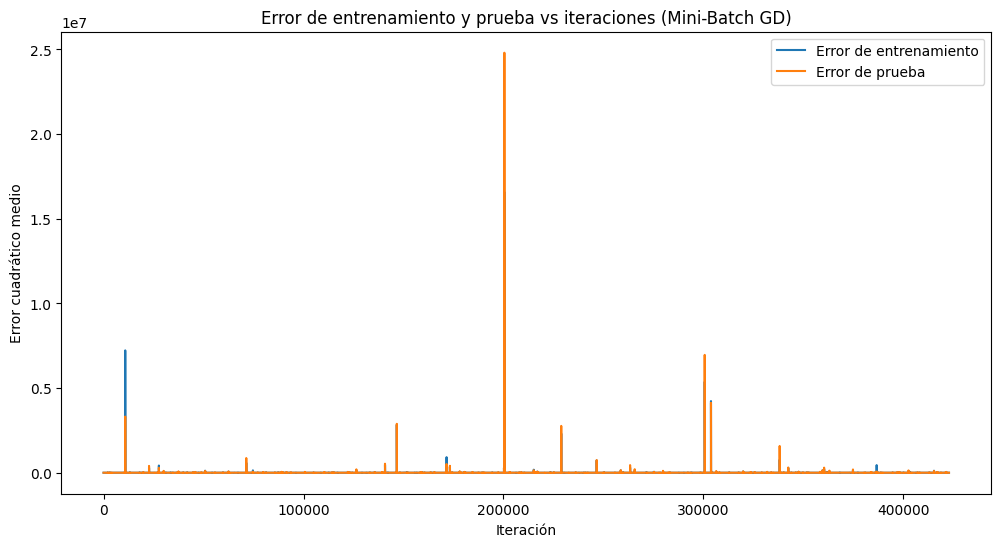

lr = 0.1
Mejor validation MSE: 15.555204731858723
Mejor iteración: 416473
----------------------------------------


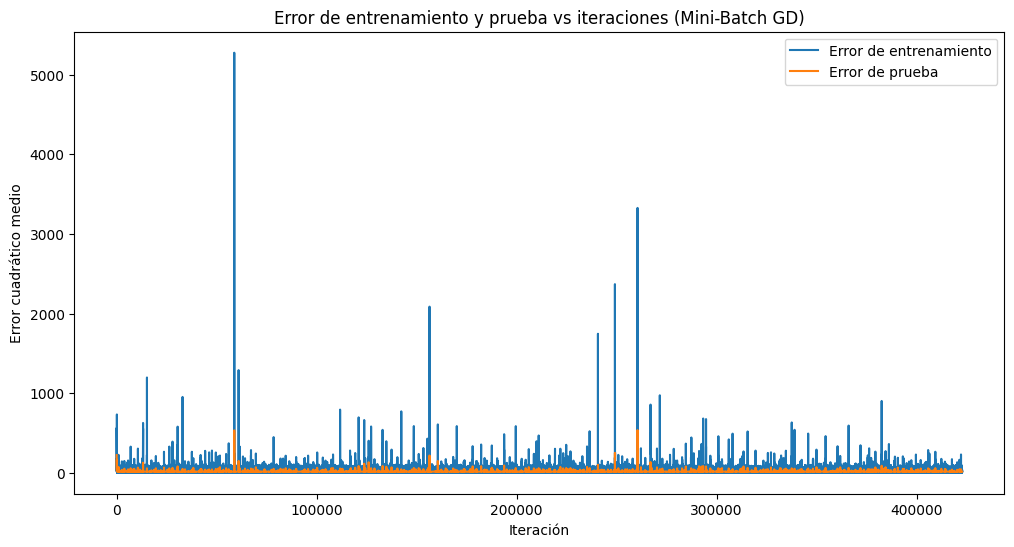

lr = 0.01
Mejor validation MSE: 15.311688825427753
Mejor iteración: 413378
----------------------------------------


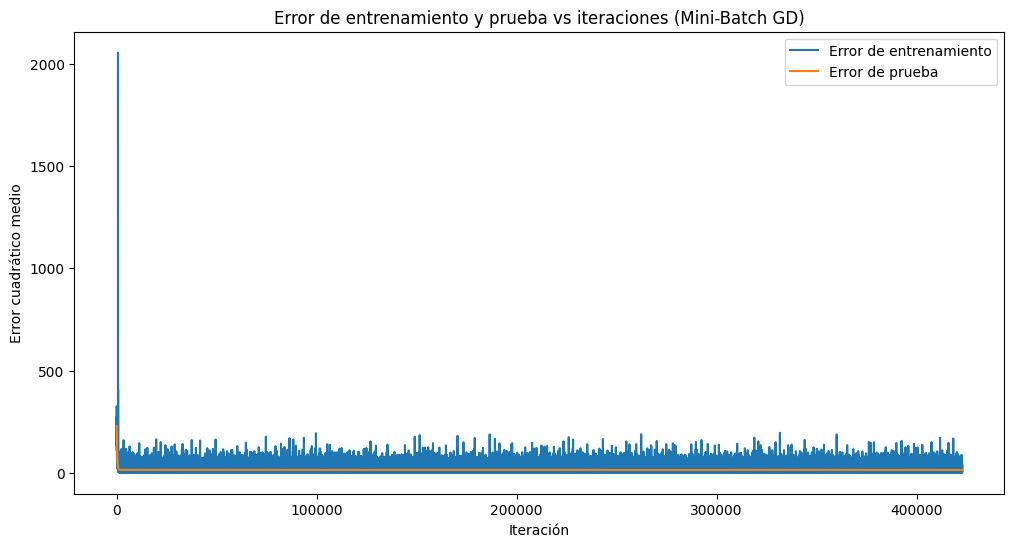

lr = 0.001
Mejor validation MSE: 15.329946676701868
Mejor iteración: 170322
----------------------------------------


In [ ]:
mbgd_lrs = [0.1, 0.01, 0.001]
batches = [32, 64, 96]
resultados_mbgd = {}

for batch in batches:
    for lr in mbgd_lrs:
        W_mbgd, train_errors, val_errors = mini_batch_gradient_descent(
            X_train_gd, y_train_gd,
            X_val_gd, y_val_gd,
            lr=lr,
            epochs=200,
            batch_size=batch
        )

        resultados_mbgd[lr] = {
            "W_mbgd": W_mbgd,
            "batch": batch,
            "train_errors": train_errors,
            "val_errors": val_errors,
            "mejor_val_mse": min(val_errors),
            "mejor_epoch": np.argmin(val_errors) + 1
        }

        print(f"lr = {lr} y batch_size = {batch}")
        print(f"Mejor validation MSE: {min(val_errors)}")
        print(f"Mejor iteración: {np.argmin(val_errors) + 1}")
        print("-" * 40)

Al usar lr menores que 0.1 se puede ver que el error del de la validación difiere mucho con el error de entrenamiento. Se decide definir lr cómo 0.1 y trabajar sobre 10 epochs. JUSTIFICAR

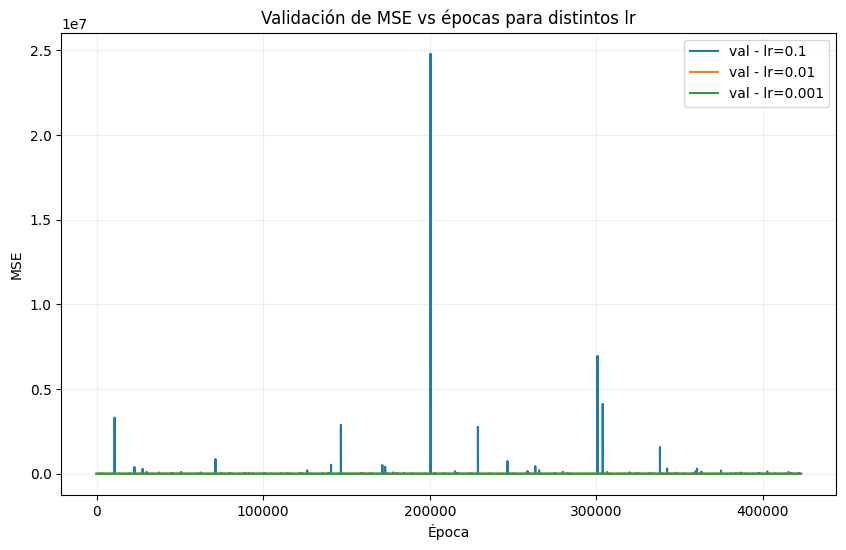

In [ ]:
plt.figure(figsize=(10, 6))

for batch in batches:
    for lr in mbgd_lrs:
        plt.plot(resultados_mbgd[lr]["val_errors"], label=f"val - lr={lr}")

    plt.xlabel("Época")
    plt.ylabel("MSE")
    plt.title(f"Validación de MSE vs épocas para distintos lr con batch_size: {batch}")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.ylim(0, 100)  # pequeña trampilla hecha para que los graficos no se ensucien tanto
    plt.show()

NOTA setear topes en todos los graficos para que los outliers no arruinen los graficos

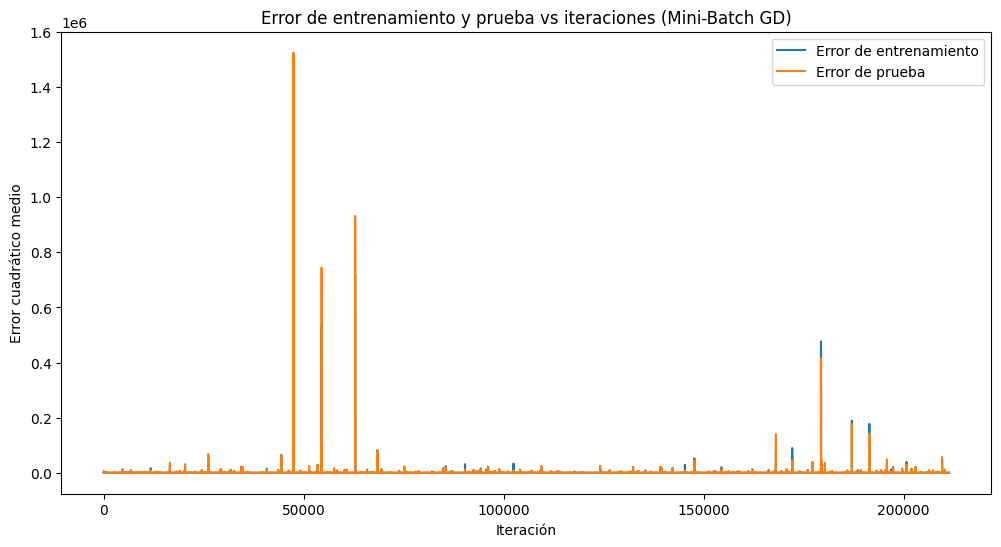

In [ ]:
W_mbgd, train_errors_mbgd, val_errors_mbgd = mini_batch_gradient_descent(
    X_train_gd, y_train_gd,
    X_val_gd, y_val_gd,
    lr=0.1,
    epochs=10,
    batch_size= 64
)

idem arriba

In [ ]:
X_train_mbgd_bias = np.hstack((np.ones((X_train_gd.shape[0], 1)), X_train_gd))
X_test_mbgd_bias = np.hstack((np.ones((X_test_gd.shape[0], 1)), X_test_gd))

y_pred_train_mbgd = np.matmul(X_train_gd_bias, W_mbgd).ravel()
y_pred_test_mbgd = np.matmul(X_test_gd_bias, W_mbgd).ravel()

tabla_metricas_mbgd = resumen_metricas(
    "Mini-Batch Gradient Descent",
    y_train_gd.ravel(),
    y_pred_train_mbgd,
    y_test_gd.ravel(),
    y_pred_test_mbgd
)

tabla_metricas_mbgd

Métricas del modelo: Mini-Batch Gradient Descent


,Train,Test
R2,0.769715,0.775985
MSE,15.492811,15.136011
RMSE,3.936091,3.890503
MAE,2.259334,2.250559


Este modelo explica un 78.1% de la variabilidad de los datos de test con un error máximo de 3.84usd.

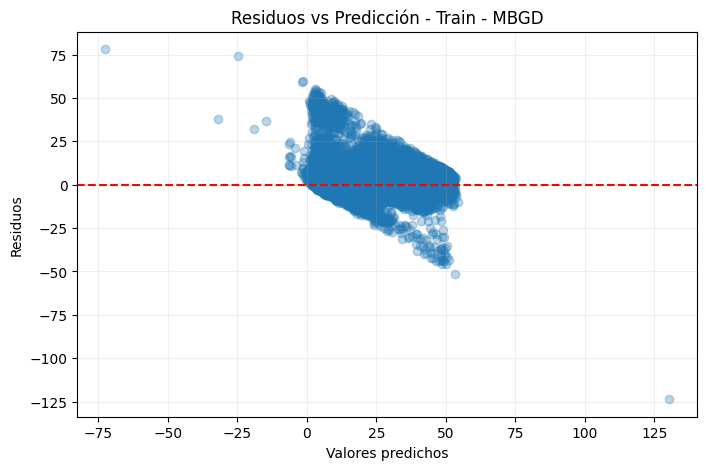

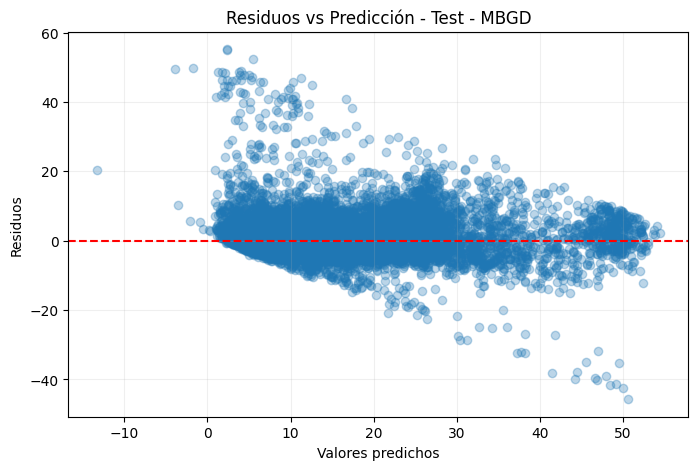

In [ ]:
grafico_residuos(
    y_train_gd.ravel(),
    y_pred_train_mbgd,
    "Residuos vs Predicción - Train - MBGD"
)

grafico_residuos(
    y_test_gd.ravel(),
    y_pred_test_mbgd,
    "Residuos vs Predicción - Test - MBGD"
)

Se llega a la misma conclusión que en los modelos previos, el patrón del ruido sugiere que hay un sesgo en los datos, el cuál se atribuye a variables invisibles para el dataset.

In [ ]:
comparacion_descenso_gradiente = pd.DataFrame({
    "Modelo": ["GD Batch", "SGD", "Mini-Batch GD"],
    "R2 Train": [
        tabla_metricas_gd.loc["R2", "Train"],
        tabla_metricas_sgd.loc["R2", "Train"],
        tabla_metricas_mbgd.loc["R2", "Train"]
    ],
    "R2 Test": [
        tabla_metricas_gd.loc["R2", "Test"],
        tabla_metricas_sgd.loc["R2", "Test"],
        tabla_metricas_mbgd.loc["R2", "Test"]
    ],
    "RMSE Train": [
        tabla_metricas_gd.loc["RMSE", "Train"],
        tabla_metricas_sgd.loc["RMSE", "Train"],
        tabla_metricas_mbgd.loc["RMSE", "Train"]
    ],
    "RMSE Test": [
        tabla_metricas_gd.loc["RMSE", "Test"],
        tabla_metricas_sgd.loc["RMSE", "Test"],
        tabla_metricas_mbgd.loc["RMSE", "Test"]
    ]
})

comparacion_descenso_gradiente

,Modelo,R2 Train,R2 Test,RMSE Train,RMSE Test
0,GD Batch,0.778217,0.781844,3.862753,3.839286
1,SGD,0.759747,0.764955,4.020375,3.985136
2,Mini-Batch GD,0.769715,0.775985,3.936091,3.890503


Se comparan las métricas de los tres métodos de descenso por gradiente. Usando cómo criterio R2 y RMSE ya que R2 explica que tan bien predice el modelo la variabilidad delos datos y RMSE indica que tanto error puede tener una predicción contra el valor real. EXPLICAR POR QUÉ SE USA O NO SE USA MAE

In [ ]:
alphas = np.logspace(-4, 2, 40)

Se determinan un rango de alphas para empezar a regularizar.

In [ ]:
def evaluar_modelo_regularizado(nombre_modelo, modelo, X_train, y_train, X_test, y_test, nombres_variables):
    modelo.fit(X_train, y_train)

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    print(f"Modelo: {nombre_modelo}")

    if hasattr(modelo, "alpha_"):
        print("Mejor alpha:", modelo.alpha_)

    if hasattr(modelo, "l1_ratio_"):
        print("Mejor l1_ratio:", modelo.l1_ratio_)

    print("\nIntercepto:")
    print(modelo.intercept_)

    tabla_metricas = resumen_metricas(
        nombre_modelo,
        y_train, y_pred_train,
        y_test, y_pred_test
    )

    coeficientes = pd.DataFrame({
        "Variable": nombres_variables,
        "Coeficiente": modelo.coef_
    }).sort_values(by="Coeficiente", key=np.abs, ascending=False)

    return modelo, tabla_metricas, coeficientes, y_pred_train, y_pred_test

Se prepara una función auxiliar para realizar las regulaciones.

In [ ]:
modelo_ridge = RidgeCV(
    alphas=alphas,
    cv=5
)

modelo_ridge, tabla_metricas_ridge, coeficientes_ridge, y_pred_train_ridge, y_pred_test_ridge = evaluar_modelo_regularizado(
    "Ridge",
    modelo_ridge,
    x_train_escalado, y_train,
    x_test_escalado, y_test,
    x_train.columns
)

tabla_metricas_ridge

Modelo: Ridge
Mejor alpha: 0.0001

Intercepto:
10.852114245051055
Métricas del modelo: Ridge


,Train,Test
R2,0.778012,0.782317
MSE,14.967212,14.708153
RMSE,3.868748,3.835121
MAE,2.193354,2.183219


se oberva un rendimiento similar al de los modelos de descenso por gradiente.

In [ ]:
coeficientes_ridge.head()

,Variable,Coeficiente
6,distance_km,6.951478
5,year,0.883384
3,dropoff_latitude,-0.507940
0,pickup_longitude,0.457170
37,hour_14,0.275137


In [65]:
coeficientes_ridge.tail()

NameError: name 'coeficientes_ridge' is not defined

se aprecia que el mayor predictor es la distancia y luego el año, posiblemente por la inflación entre cada año, el resto de variables tienen tanto peso.

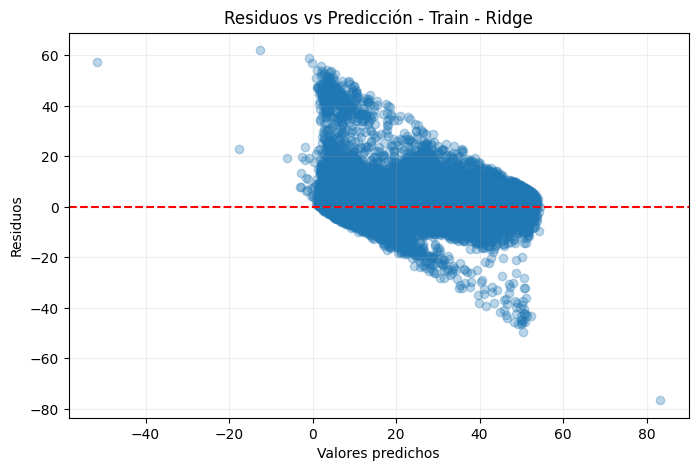

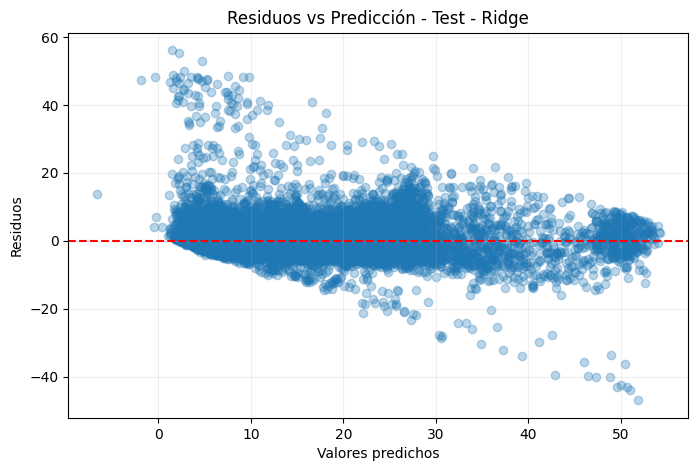

In [ ]:
grafico_residuos(y_train, y_pred_train_ridge, "Residuos vs Predicción - Train - Ridge")
grafico_residuos(y_test, y_pred_test_ridge, "Residuos vs Predicción - Test - Ridge")

Se observan patrones de ruido similares al de modelos previos.

In [ ]:
modelo_lasso = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=10000,
    random_state=42
)

modelo_lasso, tabla_metricas_lasso, coeficientes_lasso, y_pred_train_lasso, y_pred_test_lasso = evaluar_modelo_regularizado(
    "Lasso",
    modelo_lasso,
    x_train_escalado, y_train,
    x_test_escalado, y_test,
    x_train.columns
)

tabla_metricas_lasso

Modelo: Lasso
Mejor alpha: 0.0004124626382901352

Intercepto:
10.852114245051055
Métricas del modelo: Lasso


,Train,Test
R2,0.778011,0.782313
MSE,14.967266,14.708445
RMSE,3.868755,3.835159
MAE,2.193238,2.183126


No se observan mejoras con respecto a los métodos empleados previamente.

In [ ]:
coeficientes_lasso.head()

,Variable,Coeficiente
6,distance_km,6.950951
5,year,0.882788
3,dropoff_latitude,-0.506645
0,pickup_longitude,0.457453
37,hour_14,0.268965


In [ ]:
coeficientes_lasso.tail()

,Variable,Coeficiente
46,hour_23,0.012178
44,hour_21,0.007265
28,hour_5,-0.006761
45,hour_22,-0.000327
7,month_2,0.000000


Se observa que mediante Lasso se puede eliminar el coeficiente de una variable.

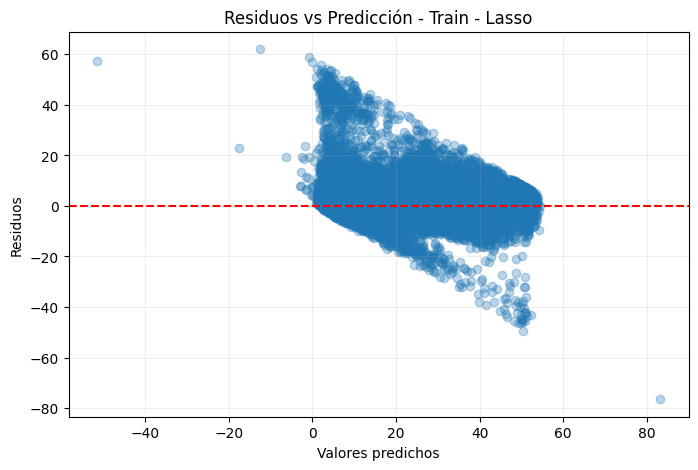

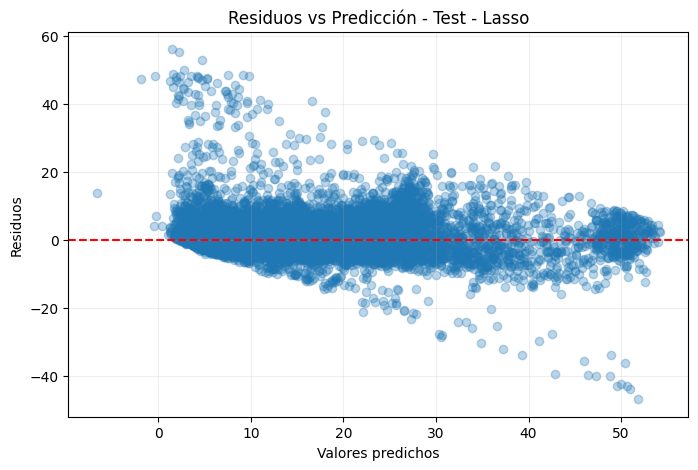

In [ ]:
grafico_residuos(y_train, y_pred_train_lasso, "Residuos vs Predicción - Train - Lasso")
grafico_residuos(y_test, y_pred_test_lasso, "Residuos vs Predicción - Test - Lasso")

No se aprecian diferencias notables en el patrón de la distribución de residuos con respecto a ejemplos anteriores.

In [ ]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

modelo_enet = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    max_iter=10000,
    random_state=42
)

modelo_enet, tabla_metricas_enet, coeficientes_enet, y_pred_train_enet, y_pred_test_enet = evaluar_modelo_regularizado(
    "Elastic Net",
    modelo_enet,
    x_train_escalado, y_train,
    x_test_escalado, y_test,
    x_train.columns
)

tabla_metricas_enet

Modelo: Elastic Net
Mejor alpha: 0.0004124626382901352
Mejor l1_ratio: 0.9

Intercepto:
10.852114245051055
Métricas del modelo: Elastic Net


,Train,Test
R2,0.778011,0.782314
MSE,14.967259,14.708391
RMSE,3.868754,3.835152
MAE,2.193261,2.183146


Al hacer el modelo con Elastic Net se obtien resultados similares a los ya vistos.

In [ ]:
coeficientes_enet.head()

,Variable,Coeficiente
6,distance_km,6.950656
5,year,0.882815
3,dropoff_latitude,-0.506763
0,pickup_longitude,0.457487
37,hour_14,0.269377


In [66]:
coeficientes_enet.tail()

NameError: name 'coeficientes_enet' is not defined

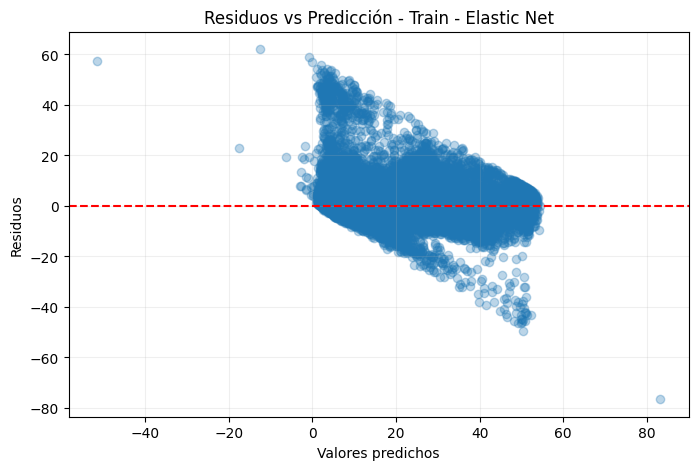

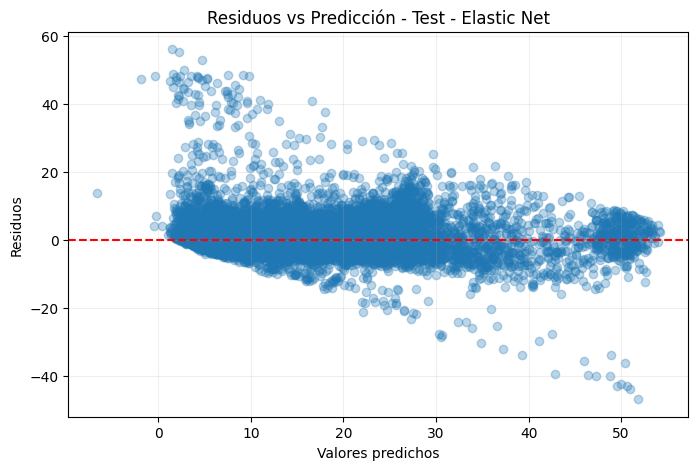

In [ ]:
grafico_residuos(y_train, y_pred_train_enet, "Residuos vs Predicción - Train - Elastic Net")
grafico_residuos(y_test, y_pred_test_enet, "Residuos vs Predicción - Test - Elastic Net")

Al realizar todos los modelados se aprecia que la distribución de residuos da similar en los 7 casos, lo que reafirma la hipotesis de que el sesgo presente en los datos es por un modelo incapaz de predecir del todo la complejidad de la variable target ya que le falta información relevante cómo la demanda del servicio en el momento del viaje, si la hora es hora pico o no, clima en ese momento y demás de factores internos de la empresa.

In [ ]:
comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "GD Batch",
        "SGD",
        "Mini-Batch GD",
        "Ridge",
        "Lasso",
        "Elastic Net"
    ],
    "R2 Test": [
        tabla_metricas_lr.loc["R2", "Test"],
        tabla_metricas_gd.loc["R2", "Test"],
        tabla_metricas_sgd.loc["R2", "Test"],
        tabla_metricas_mbgd.loc["R2", "Test"],
        tabla_metricas_ridge.loc["R2", "Test"],
        tabla_metricas_lasso.loc["R2", "Test"],
        tabla_metricas_enet.loc["R2", "Test"]
    ],
    "RMSE Test": [
        tabla_metricas_lr.loc["RMSE", "Test"],
        tabla_metricas_gd.loc["RMSE", "Test"],
        tabla_metricas_sgd.loc["RMSE", "Test"],
        tabla_metricas_mbgd.loc["RMSE", "Test"],
        tabla_metricas_ridge.loc["RMSE", "Test"],
        tabla_metricas_lasso.loc["RMSE", "Test"],
        tabla_metricas_enet.loc["RMSE", "Test"]
    ]
}).sort_values(by="RMSE Test", ascending=True)

comparacion_modelos

,Modelo,R2 Test,RMSE Test
4,Ridge,0.782317,3.835121
0,Regresión Lineal,0.782317,3.835121
6,Elastic Net,0.782314,3.835152
5,Lasso,0.782313,3.835159
1,GD Batch,0.781844,3.839286
3,Mini-Batch GD,0.775985,3.890503
2,SGD,0.764955,3.985136


Al comparar las métricas finales de todos los modelos se concluye que el mejor modelo para este caso es Ridge, seguido por la regresión lineal. Se usa de parametro el menor RMSE ya que nos interesa que nuestro modelo tenga el menor error posible, segundo criterio es el r2, ya que también queremos que explique la variabilidad de los datos lo mejor posible, al tener todos un r2 similar, el principal criterio a tener en cuenta es el RMSE.

conclusión final:   
----
Se puede observar que luego de curar los datos, con todos los modelos se alcanza un r2 del 78%, lo que implica que nuestros modelos son capaces de explicar el 78% de la variabilidad de los datos, al adentrarnos más en la información, podemos ver que los pesos de la regresión lineal y los pesos de las regularizacions dan mucha importancia a la distancia recorrida y luego una moderada importancia al año, mientras que el resto de factores cómo hora, día de la semana, mes, etc quedan con coeficientes muy bajos, casi nulos. Eso nos lleva a pensar que el principal factor del precio de un viaje es la distancia recorrida, que es una conclusión lógica, y el año, que se lo atribuimos a la inflación interanual que lleva a que cada año el "mismo servicio" valga más. Pero no podemos obviar tampoco que existen otras variables, que nuestro dataset no contempla, que afectan directamente al precio de un viaje, tales cómo, hora pico, demanda, tipo de zona, clima, entre otras, de todas formas, según nuestros modelos, sólo con la distancia y el año se logra explicar el 78% de la variabilidad de los datos, con lo cuál se concluye que es un buen fitting.  
Al hacer gradiente descendiente se llega por todos los métodos al mismo resultado, con lo cuál se puede afirmar que el problema es convexo y tiene un sólo minimo global. Al hacer la regularización de los datos se llega a resultados similares que con descenso por gradiente o regresión lineal, lo que sugiere que no había ningún underfitting y que la regresión lineal ya respondía correctamente al problema. 